# NFL ATS — Model Comparison

Compares 5 model architectures and 3 ensemble variants on the production dataset.
The goal: find out if anything beats the baseline on ATS accuracy, and tune hyperparameters / feature selection.

| Model | Type |
|-------|------|
| XGBoost | Gradient boosted trees — direction voter |
| Random Forest | Bagged decision trees — comparison only |
| Ridge Regression | Linear model — direction voter |
| LightGBM | Gradient boosted trees (leaf-wise) — direction voter |
| MLP (PyTorch) | 3-layer feedforward neural network — comparison only |

**What we're predicting:** home margin (home score − away score).
**How we measure success:** ATS accuracy — does the model pick the right side of the spread? Break-even is 52.4%.

**Production setup:** Ensemble fixed75 is the primary model (edge-setter). XGBoost, Ridge, and LightGBM are the three direction voters. All three must agree on direction for a HIGH or MEDIUM confidence pick.

**Feature set (2026-05-20):** 85 features engineered into `g`; top 35 (by combined XGB gain + Ridge |coef| + LGB gain) are passed to model training via `PROD_FEATURES_35` in cell 33. The 50 features below the cut stay in `g` for reference and future ablation.

**Tuned hyperparameters (2026-05-20):** Ridge α=50 (was 10), XGBoost reg_alpha=2 reg_lambda=5 (was 1/3). LightGBM baseline unchanged.

---

### Notebook conventions

Each section uses a **markdown header → code → inline test** pattern:
- The markdown header states the section's *purpose*, *inputs*, *outputs*, and what the *test cell* checks.
- The code cell does the work.
- The test cell at the end of each section asserts shape, null, and range invariants so regressions fail loudly at the section boundary instead of leaking downstream.

Tests are intentionally light (shape / null / range only) so reruns stay fast. They are **not** a substitute for the walk-forward CV in Section 20 — they catch *plumbing* bugs, not modelling regressions.

## Section 1. Configuration

**Purpose:** Set training window, test years, and coach history window.
**Inputs:** None.
**Outputs:** `TRAIN_SEASONS`, `TEST_SEASONS`, `COACH_SEASONS`, `ALL_SEASONS`, `ALLPRO_CSV`.
**Tests:** seasons match expected lists; All-Pro CSV is reachable.


In [38]:
TRAIN_SEASONS  = list(range(2014, 2023))   # 2014-2022
TEST_SEASONS   = [2023, 2024, 2025]        # extended to include 2025 live season
COACH_SEASONS  = list(range(1999, 2026))   # longer window for cumulative coach W%
ALL_SEASONS    = TRAIN_SEASONS + TEST_SEASONS

from pathlib import Path
# Try both paths
ALLPRO_CSV = next(
    (p for p in [Path("nfl_allpro_1997_2025.csv"), Path("betting/nfl_allpro_1997_2025.csv")]
     if p.exists()),
    Path("betting/nfl_allpro_1997_2025.csv")
)

# NOTE: 2025 added to TEST_SEASONS — re-run from cell 3 onwards to pull new data.


In [39]:
# ── Section 1 tests ──
assert min(TRAIN_SEASONS) == 2014 and max(TRAIN_SEASONS) == 2022, "TRAIN_SEASONS should span 2014-2022"
assert TEST_SEASONS == [2023, 2024, 2025], f"TEST_SEASONS unexpected: {TEST_SEASONS}"
assert COACH_SEASONS[0] == 1999, "Coach history must start at 1999 for cumulative win%"
assert ALL_SEASONS == TRAIN_SEASONS + TEST_SEASONS, "ALL_SEASONS != TRAIN + TEST"
if not ALLPRO_CSV.exists():
    import warnings as _w
    _w.warn(f"All-Pro CSV not found at {ALLPRO_CSV} — Section 5 will zero-fill the 6 All-Pro columns and the comparison will run with degraded features.")
print(f"✓ Section 1 tests passed | TRAIN {TRAIN_SEASONS[0]}-{TRAIN_SEASONS[-1]}, TEST {TEST_SEASONS}")


✓ Section 1 tests passed | TRAIN 2014-2022, TEST [2023, 2024, 2025]


## Section 2. Setup — Imports & Dependencies

**Purpose:** Import xgboost, lightgbm, sklearn, nflreadpy, pandas, matplotlib, and PyTorch (for MLP). Pip-install any missing packages on first run.
**Inputs:** Section 1.
**Outputs:** All ML/data libraries; the empty `RESULTS` dict that each model section later appends to.
**Tests:** key modules are bound; `RESULTS` starts empty.


In [40]:
# Polars >= 1.x is strict about UTF-8 in parquet files; nflverse data
# occasionally contains non-UTF-8 strings. Fall back to pyarrow on failure.
import polars as _pl
_pl_read_parquet_orig = _pl.read_parquet
def _pl_read_parquet_lenient(source, *args, **kwargs):
    try:
        return _pl_read_parquet_orig(source, *args, **kwargs)
    except Exception:
        kwargs.setdefault('use_pyarrow', True)
        return _pl_read_parquet_orig(source, *args, **kwargs)
_pl.read_parquet = _pl_read_parquet_lenient

import subprocess, sys, warnings
warnings.filterwarnings("ignore")

# Try imports first; only pip-install if anything is missing
_required = ["nflreadpy", "xgboost", "lightgbm", "scikit-learn", "matplotlib", "seaborn"]
try:
    import xgboost as xgb
    import lightgbm as lgb
    import nflreadpy as nfl
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.linear_model import Ridge
    from sklearn.preprocessing import OrdinalEncoder, StandardScaler
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    import matplotlib.pyplot as plt
except ImportError as _e:
    print(f"Installing missing packages ({_e})...")
    _r = subprocess.run([sys.executable, "-m", "pip", "install", *_required],
                        capture_output=True, text=True)
    if _r.returncode != 0:
        print(f"WARNING: pip install failed:\n{_r.stderr[:500]}")
    import xgboost as xgb
    import lightgbm as lgb
    import nflreadpy as nfl
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.linear_model import Ridge
    from sklearn.preprocessing import OrdinalEncoder, StandardScaler
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    import matplotlib.pyplot as plt

import numpy as np, pandas as pd

# PyTorch for MLP
try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False
    print("WARNING: torch not installed — MLP section will be skipped")

RESULTS = {}   # accumulates {model_name: {mae, rmse, ats_acc, preds}}


In [41]:
# ── Section 2 tests ──
assert RESULTS == {}, "RESULTS should start empty before any model runs"
for _name, _mod in [("xgb", xgb), ("lgb", lgb), ("nfl", nfl), ("pd", pd), ("np", np), ("plt", plt)]:
    assert _mod is not None, f"{_name} not imported"
assert hasattr(RandomForestRegressor, "fit") and hasattr(Ridge, "fit"), "sklearn models not loaded"
assert HAS_TORCH, "torch not installed — MLP cannot run; install pytorch"
print("✓ Section 2 tests passed | all imports OK, RESULTS={}, torch=" + torch.__version__)


✓ Section 2 tests passed | all imports OK, RESULTS={}


## Section 3. Data Loading — Schedules & Play-by-Play

**Purpose:** Pull NFL schedules (1999–2025 for coach history; 2014–2025 for the working set) and play-by-play (2014–2025). Filters PBP to run/pass plays with both `posteam` and `defteam` populated.
**Inputs:** Section 1 (season lists).
**Outputs:** `sched_full` (full schedule history), `sched` (completed games in `ALL_SEASONS`), `pbp_full`, `pbp_rp` (run/pass plays), `week_lkp`.
**Tests:** `sched` non-empty, only completed games, covers expected seasons; `pbp_rp` non-empty with valid play types.


In [42]:
print(f"Loading schedules {min(COACH_SEASONS)}-{max(COACH_SEASONS)}...")
sched_full = nfl.load_schedules(COACH_SEASONS).to_pandas()

# Working set: completed games in model seasons
sched = sched_full[sched_full["season"].isin(ALL_SEASONS)].copy()
sched = sched[sched["result"].notna()].copy()
print(f"  completed games: {len(sched):,}")

print(f"Loading PBP {min(ALL_SEASONS)}-{max(ALL_SEASONS)} (takes ~2 min)...")
pbp_full = nfl.load_pbp(ALL_SEASONS).to_pandas()
pbp_rp   = pbp_full[
    pbp_full["play_type"].isin(["run","pass"]) &
    pbp_full["posteam"].notna() & pbp_full["defteam"].notna()
].copy()
print(f"  run/pass plays: {len(pbp_rp):,}")

week_lkp = sched[["game_id","week","season"]].drop_duplicates()

Loading schedules 1999-2025...
  completed games: 3,295
Loading PBP 2014-2025 (takes ~2 min)...
  run/pass plays: 412,591


In [43]:
# ── Section 3 tests ──
assert not sched.empty, "sched is empty"
assert sched["result"].notna().all(), "sched should only contain completed games (result is NaN)"
_expected = set(ALL_SEASONS)
_have = set(sched["season"].unique())
assert _expected - _have <= {2025}, f"unexpected season gap in sched: missing {_expected - _have}"
if 2025 not in _have:
    import warnings as _w; _w.warn("2025 season not yet in sched — walk-forward fold 6 will be empty")
assert not pbp_rp.empty, "pbp_rp is empty"
assert set(pbp_rp["play_type"].unique()) <= {"run", "pass"}, "pbp_rp should only contain run/pass plays"
assert pbp_rp["posteam"].notna().all() and pbp_rp["defteam"].notna().all(), "pbp_rp has null team columns"
assert set(week_lkp.columns) == {"game_id", "week", "season"}, f"week_lkp columns off: {week_lkp.columns.tolist()}"
print(f"✓ Section 3 tests passed | sched={len(sched):,}  pbp_rp={len(pbp_rp):,}")


✓ Section 3 tests passed | sched=3,295  pbp_rp=412,591


## Section 4. Rolling Offense/Defense Stats + Team Pivot

**Purpose:** Build per-game offense and defense rolling means (5-game window, shifted by 1 to avoid leakage), then pivot the schedule into a long-format team-game table with rolling win%, scoring, points-allowed, cover rate, and strength-of-schedule (recent 3-game opponent W% and season-long expanding opponent W%).
**Inputs:** Section 3 (`sched`, `pbp_rp`, `week_lkp`).
**Outputs:** `off`, `def_`, `long` (team-game format with rolling stats), `opp_lkp`.
**Tests:** rolling columns present on `long`; win% and SOS columns lie in `[0, 1]` (after dropna).


In [44]:
# ── Offense stats ──────────────────────────────────────────────────────────────
off = (pbp_rp.groupby(["game_id","posteam"])
       .agg(avg_epa=("epa","mean"), avg_yards=("yards_gained","mean"),
            play_count=("play_id","count"))
       .reset_index().rename(columns={"posteam":"team"})
       .merge(week_lkp, on="game_id", how="left")
       .sort_values(["team","season","week"]))
# ── Defense stats ──────────────────────────────────────────────────────────────
def_ = (pbp_rp.groupby(["game_id","defteam"])
        .agg(allowed_avg_epa=("epa","mean"), allowed_avg_yards=("yards_gained","mean"),
             allowed_play_count=("play_id","count"))
        .reset_index().rename(columns={"defteam":"team"})
        .merge(week_lkp, on="game_id", how="left")
        .sort_values(["team","season","week"]))

for feat in ["avg_epa","avg_yards","play_count"]:
    off[f"rolling_{feat}"] = off.groupby("team")[feat].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean())
for feat in ["allowed_avg_epa","allowed_avg_yards","allowed_play_count"]:
    def_[f"rolling_{feat}"] = def_.groupby("team")[feat].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean())

# ── Long-format team-game table ────────────────────────────────────────────────
hg = sched[["game_id","season","week","home_team","away_team",
             "home_score","away_score","spread_line","result"]].copy()
hg.columns = ["game_id","season","week","team","opponent","ts","os","spread_line","result"]
ag = sched[["game_id","season","week","away_team","home_team",
             "away_score","home_score","spread_line","result"]].copy()
ag.columns = ["game_id","season","week","team","opponent","ts","os","spread_line","result"]
long = pd.concat([hg,ag],ignore_index=True).sort_values(["team","season","week"])
long["team_win"] = (long["ts"] > long["os"]).astype(int)

# Rolling win pct / scoring / cover rate
long["rolling_win_pct"] = long.groupby("team")["team_win"].transform(
    lambda x: x.shift(1).rolling(5,min_periods=1).mean())
long["covered"] = (long["result"] > long["spread_line"]).astype(int)
for col, feat in [("rolling_scored","ts"),("rolling_allowed","os")]:
    long[col] = long.groupby("team")[feat].transform(
        lambda x: x.shift(1).rolling(5,min_periods=1).mean())
long["rolling_cover_rate"] = long.groupby("team")["covered"].transform(
    lambda x: x.shift(1).rolling(5,min_periods=1).mean())

print("Long-format:", long.shape)

Long-format: (6590, 15)


In [45]:
long["cum_win_pct"] = long.groupby("team")["team_win"].transform(
    lambda x: x.shift(1).expanding().mean())

opp_lkp = long[["game_id","team","cum_win_pct"]].rename(
    columns={"team":"opponent","cum_win_pct":"opp_win_pct"})
long = long.merge(opp_lkp, on=["game_id","opponent"], how="left")

long["recent_sos_opponent_avg"] = long.groupby("team")["opp_win_pct"].transform(
    lambda x: x.shift(1).rolling(3,min_periods=1).mean().fillna(0))
long["season_sos_opponent_avg"] = long.groupby("team")["opp_win_pct"].transform(
    lambda x: x.shift(1).expanding().mean().fillna(0))
print("SOS done")

SOS done


In [46]:
# ── Section 4 tests ──
for _c in ["rolling_win_pct", "rolling_scored", "rolling_allowed", "rolling_cover_rate",
          "recent_sos_opponent_avg", "season_sos_opponent_avg"]:
    assert _c in long.columns, f"{_c} missing from long"
# rolling_win_pct is shift(1).rolling — first game per team is NaN; ignore those
_wp = long["rolling_win_pct"].dropna()
assert _wp.between(0.0, 1.0).all(), f"rolling_win_pct out of [0,1]: min={_wp.min()} max={_wp.max()}"
_sos = long["recent_sos_opponent_avg"]
assert _sos.between(0.0, 1.0).all(), "recent_sos_opponent_avg out of [0,1]"
assert (long["rolling_scored"].dropna() >= 0).all(), "rolling_scored cannot be negative"
print(f"✓ Section 4 tests passed | long={long.shape}")


✓ Section 4 tests passed | long=(6590, 19)


## Section 5. All-Pro Roster Features

**Purpose:** Attach weighted (4/2/1 over 3 prior seasons) and previous-year All-Pro counts to each team-game row, split by side (offense vs defense). Player names are deduplicated within a season so a single multi-Pro doesn't inflate a team's score.
**Inputs:** Section 4 (`long`), `betting/nfl_allpro_1997_2025.csv`.
**Outputs:** 6 new columns on `long`: `allpro_last_3_years_weighted`, `offense_allpro_3_years`, `defense_allpro_3_years`, `allpro_prev_year`, `offense_allpro_prev_year`, `defense_allpro_prev_year`.
**Tests:** all 6 columns are present and non-negative.


In [47]:
TEAM_MAP = {"STL":"LA","LAR":"LA","OAK":"LV","LVR":"LV","SD":"LAC","SDG":"LAC",
            "NWE":"NE","KAN":"KC","GNB":"GB","NOR":"NO","TAM":"TB","SFO":"SF"}

def build_weighted(df_ap):
    rows = []
    for yr in range(2006, max(ALL_SEASONS)+2):
        for back, w in zip([1,2,3],[4,2,1]):
            tmp = df_ap[df_ap["Year"]==yr-back].copy()
            tmp["weight"], tmp["season"] = w, yr
            rows.append(tmp)
    combined = pd.concat(rows)
    deduped  = combined.sort_values("weight",ascending=False).drop_duplicates(["Player","season"])
    return (deduped.groupby(["season","Team"])["weight"].sum()
            .reset_index().rename(columns={"weight":"val"}))

if ALLPRO_CSV.exists():
    ap = pd.read_csv(ALLPRO_CSV)
    ap = ap[ap["Team"]!="2TM"].copy()
    ap["Team"] = ap["Team"].replace(TEAM_MAP)

    ap_overall = build_weighted(ap).rename(columns={"val":"allpro_last_3_years_weighted"})
    ap_off_w   = build_weighted(ap[ap["Side"]=="offense"]).rename(columns={"val":"offense_allpro_3_years"})
    ap_def_w   = build_weighted(ap[ap["Side"]=="defense"]).rename(columns={"val":"defense_allpro_3_years"})

    def prev_year(df_ap, col):
        return (df_ap.assign(season=df_ap["Year"]+1)
                .groupby(["season","Team","Side"])["Player"].nunique()
                .reset_index(name=col))

    ap_prev_off = prev_year(ap,"allpro_prev_year")[lambda d: d["Side"]=="offense"].drop(columns="Side")
    ap_prev_def = prev_year(ap,"allpro_prev_year")[lambda d: d["Side"]=="defense"].drop(columns="Side")
    ap_prev_all = (ap.assign(season=ap["Year"]+1)
                   .groupby(["season","Team"])["Player"].nunique()
                   .reset_index(name="allpro_prev_year"))

    def merge_ap(df, ap_df, val_col):
        return df.merge(ap_df.rename(columns={"Team":"team"}),
                        on=["season","team"], how="left").fillna({val_col:0})

    long = merge_ap(long, ap_overall, "allpro_last_3_years_weighted")
    long = merge_ap(long, ap_off_w,   "offense_allpro_3_years")
    long = merge_ap(long, ap_def_w,   "defense_allpro_3_years")
    long = merge_ap(long, ap_prev_all,"allpro_prev_year")
    long = merge_ap(long, ap_prev_off.rename(columns={"allpro_prev_year":"offense_allpro_prev_year"}), "offense_allpro_prev_year")
    long = merge_ap(long, ap_prev_def.rename(columns={"allpro_prev_year":"defense_allpro_prev_year"}), "defense_allpro_prev_year")
else:
    for col in ["allpro_last_3_years_weighted","offense_allpro_3_years","defense_allpro_3_years",
                "allpro_prev_year","offense_allpro_prev_year","defense_allpro_prev_year"]:
        long[col] = 0
    print("WARNING: allpro CSV not found")

print("All-pro done")

All-pro done


In [48]:
# ── Section 5 tests ──
_allpro_cols = ["allpro_last_3_years_weighted", "offense_allpro_3_years", "defense_allpro_3_years",
                "allpro_prev_year", "offense_allpro_prev_year", "defense_allpro_prev_year"]
for _c in _allpro_cols:
    assert _c in long.columns, f"{_c} missing from long"
    assert (long[_c] >= 0).all(), f"{_c} has negative values"
print(f"✓ Section 5 tests passed | 6 All-Pro columns populated")


✓ Section 5 tests passed | 6 All-Pro columns populated


## Section 6. Prior-Year QB NGS Features (Passer Rating, CPAE, Time to Throw)

**Purpose:** Compute each team's primary QB passer rating from the **prior season**, joined onto the current season as `pr_prev_year`. Pulled from **NFL Next Gen Stats** (`nfl.load_nextgen_stats(stat_type="passing")`) for 2016+ — the official league source — and falls back to a manual NFL-passer-rating formula on PBP for 2014–2015 (NGS does not cover pre-2016). Both sources filter to QBs with ≥ 100 attempts and pick the primary starter per team. The minimum-attempt filter and primary-starter selection are identical in both branches.

NGS team abbreviations are canonicalised to match the schedule's per-season convention (e.g. NGS `LAR` → schedule `LA`; `LV` → `OAK` for 2016–2019; `LAC` → `SD` for 2016). This is done by `_canonicalize_ngs_team`.

**Inputs:** Section 1 (`ALL_SEASONS`), Section 4 (`long`), Section 3 (`pbp_rp`).
**Outputs:** `pr_prev_year`, `cpae_prev_year`, `time_to_throw_prev_year` columns on `long`, `best_qb` lookup table, `median_pr`, `median_cpae`, `median_ttt`.
**Tests:** `pr_prev_year` no nulls, in `[0, 158.3]`, median in `[60, 110]`. `cpae_prev_year` no nulls, in `[-20, 20]`. `time_to_throw_prev_year` no nulls, in `[1, 5]`.


In [49]:
# Section 6 — Prior-season passer rating
# Source: NFL Next Gen Stats (nfl.load_nextgen_stats) for 2016+; manual formula on PBP for 2014-2015.
# NGS season aggregates live in rows where week==0; we filter to QBs with >= 100 attempts.

def _canonicalize_ngs_team(team_abbr, season):
    """NGS uses modern team abbreviations (LAR/LV/LAC) even for historical seasons.
    The PBP/schedule per-season abbreviations differ — map NGS back to that season's convention
    so the team-key merge with long works."""
    if team_abbr == "LAR":
        return "LA"
    if team_abbr == "LV":
        return "OAK" if season < 2020 else "LV"
    if team_abbr == "LAC":
        return "SD" if season < 2017 else "LAC"
    return team_abbr

# ── NGS-sourced rating for 2016+ ─────────────────────────────────────────────
_ngs_seasons = sorted(s for s in ALL_SEASONS if s >= 2016)
if _ngs_seasons:
    _ngs = nfl.load_nextgen_stats(seasons=_ngs_seasons, stat_type="passing").to_pandas()
    _ngs_agg = _ngs[(_ngs["week"]==0) & (_ngs["attempts"]>=100)].copy()
    _ngs_agg["posteam"] = _ngs_agg.apply(lambda r: _canonicalize_ngs_team(r["team_abbr"], r["season"]), axis=1)
    ngs_best = (_ngs_agg.sort_values("attempts", ascending=False)
                .groupby(["season","posteam"]).first().reset_index()
                [["season","posteam","passer_rating","completion_percentage_above_expectation","avg_time_to_throw"]])
    assert not ngs_best.duplicated(["season","posteam"]).any(), "ngs_best has duplicate (season, team) rows after canonicalization"
    print(f"NGS: {len(ngs_best):,} team-seasons covered ({min(_ngs_seasons)}-{max(_ngs_seasons)})")
else:
    ngs_best = pd.DataFrame(columns=["season","posteam","passer_rating","completion_percentage_above_expectation","avg_time_to_throw"])

# ── Manual passer rating for 2014-2015 (pre-NGS) ─────────────────────────────
_manual_seasons = sorted(s for s in ALL_SEASONS if s < 2016)
manual_best = pd.DataFrame(columns=["season","posteam","passer_rating"])
if _manual_seasons:
    pp = pbp_rp[(pbp_rp["play_type"]=="pass") &
                pbp_rp["passer_player_name"].notna() &
                pbp_rp["season"].isin(_manual_seasons)].copy()
    qbs = (pp.groupby(["season","posteam","passer_player_name"])
           .agg(att=("pass_attempt","sum"), cmp=("complete_pass","sum"),
                yds=("passing_yards","sum"), tds=("pass_touchdown","sum"), ints=("interception","sum"))
           .reset_index())
    qbs = qbs[qbs["att"]>=100]
    def _pr(r):
        a = max(0, min(((r["cmp"]/r["att"]) - 0.3) * 5,    2.375))
        b = max(0, min(((r["yds"]/r["att"]) - 3) * 0.25,   2.375))
        c = max(0, min(r["tds"]/r["att"] * 20,             2.375))
        d = max(0, min(2.375 - (r["ints"]/r["att"] * 25),  2.375))
        return ((a+b+c+d)/6) * 100
    qbs["passer_rating"] = qbs.apply(_pr, axis=1)
    manual_best = (qbs.sort_values("att", ascending=False)
                   .groupby(["season","posteam"]).first().reset_index()
                   [["season","posteam","passer_rating"]])
    print(f"Manual: {len(manual_best):,} team-seasons covered ({min(_manual_seasons)}-{max(_manual_seasons)})")

# ── Combine and shift to prior-season lookup ────────────────────────────────
best_qb = pd.concat([ngs_best, manual_best], ignore_index=True)
best_qb["season_next"] = best_qb["season"] + 1
median_pr   = best_qb["passer_rating"].median()
median_cpae = best_qb["completion_percentage_above_expectation"].dropna().median()
median_ttt  = best_qb["avg_time_to_throw"].dropna().median()

# Merge all three QB NGS features into long
long = long.merge(
    best_qb[["season_next","posteam","passer_rating",
             "completion_percentage_above_expectation","avg_time_to_throw"]].rename(
        columns={"season_next":"season","posteam":"team",
                 "passer_rating":"pr_prev_year",
                 "completion_percentage_above_expectation":"cpae_prev_year",
                 "avg_time_to_throw":"time_to_throw_prev_year"}),
    on=["season","team"], how="left")
long["pr_prev_year"]            = long["pr_prev_year"].fillna(median_pr)
long["cpae_prev_year"]          = long["cpae_prev_year"].fillna(median_cpae)
long["time_to_throw_prev_year"] = long["time_to_throw_prev_year"].fillna(median_ttt)
print(f"QB NGS features done | team-seasons: {len(best_qb):,}  median PR={median_pr:.1f}  CPAE={median_cpae:.1f}%  TTT={median_ttt:.2f}s")


NGS: 313 team-seasons covered (2016-2025)
Manual: 64 team-seasons covered (2014-2015)
QB NGS features done | team-seasons: 377  median PR=90.4  CPAE=0.4%  TTT=2.77s


In [50]:
# ── Section 6 tests ──
assert "pr_prev_year" in long.columns
_pr = long["pr_prev_year"]
assert _pr.notna().all(), "pr_prev_year has nulls (median fill failed)"
assert _pr.between(0.0, 158.5).all(), f"pr_prev_year outside NFL passer-rating range [0, 158.3]: [{_pr.min():.1f}, {_pr.max():.1f}]"
assert 60.0 <= _pr.median() <= 110.0, f"pr_prev_year median {_pr.median():.1f} outside expected [60, 110] — check median fill / formula"
assert "cpae_prev_year" in long.columns and long["cpae_prev_year"].notna().all(), "cpae_prev_year missing or has nulls"
assert long["cpae_prev_year"].between(-20.0, 20.0).all(), (
    f"cpae_prev_year outside plausible range: "
    f"[{long['cpae_prev_year'].min():.1f}, {long['cpae_prev_year'].max():.1f}]")
assert "time_to_throw_prev_year" in long.columns and long["time_to_throw_prev_year"].notna().all(), "time_to_throw_prev_year missing or has nulls"
assert long["time_to_throw_prev_year"].between(1.0, 5.0).all(), (
    f"time_to_throw_prev_year outside plausible range: "
    f"[{long['time_to_throw_prev_year'].min():.2f}s, {long['time_to_throw_prev_year'].max():.2f}s]")
# Source coverage: NGS covers 2016+, manual covers <2016, combined should cover all but possibly first training year (no prior data)
assert len(best_qb) > 0, "best_qb is empty — neither NGS nor manual produced any rows"
assert (best_qb["passer_rating"].between(0.0, 158.5)).all(), "best_qb has values outside passer-rating bound"
print(f"✓ Section 6 tests passed | pr_prev_year range [{_pr.min():.1f}, {_pr.max():.1f}]  median={_pr.median():.1f}  best_qb rows={len(best_qb):,}")
print(f"  cpae range [{long['cpae_prev_year'].min():.1f}%, {long['cpae_prev_year'].max():.1f}%]  median={long['cpae_prev_year'].median():.1f}%")
print(f"  time_to_throw range [{long['time_to_throw_prev_year'].min():.2f}s, {long['time_to_throw_prev_year'].max():.2f}s]  median={long['time_to_throw_prev_year'].median():.2f}s")


✓ Section 6 tests passed | pr_prev_year range [60.5, 121.5]  median=90.4  best_qb rows=377
  cpae range [-11.2%, 8.7%]  median=0.4%
  time_to_throw range [2.30s, 3.24s]  median=2.77s


## Section 7. Sacks / Turnovers / Third-Down

**Purpose:** Build rolling 5-game means for defensive sack rate, offensive turnovers (INT + fumble lost), and offensive 3rd-down conversion rate. All use `shift(1).rolling(5).mean()` to avoid leaking the current game.
**Inputs:** Section 3 (`pbp_rp`).
**Outputs:** `sack_pg`, `to_pg`, `td_pg` — each keyed by `game_id × team` with a `rolling_*` column.
**Tests:** rolling sacks/TOs are non-negative; rolling third-down rate is in `[0, 1]`.


In [51]:
# Sacks (defensive: defteam)
sack_pg = (pbp_rp[pbp_rp["sack"]==1]
           .groupby(["game_id","defteam"]).size().reset_index(name="sacks")
           .rename(columns={"defteam":"team"})
           .merge(week_lkp,on="game_id",how="left").sort_values(["team","season","week"]))
sack_pg["rolling_sacks"] = sack_pg.groupby("team")["sacks"].transform(
    lambda x: x.shift(1).rolling(5,min_periods=1).mean())

# Turnovers (offensive: posteam)
pbp_rp["turnover"] = ((pbp_rp["interception"]==1)|(pbp_rp["fumble_lost"]==1)).astype(int)
to_pg = (pbp_rp.groupby(["game_id","posteam"])["turnover"].sum()
         .reset_index().rename(columns={"posteam":"team"})
         .merge(week_lkp,on="game_id",how="left").sort_values(["team","season","week"]))
to_pg["rolling_turnovers"] = to_pg.groupby("team")["turnover"].transform(
    lambda x: x.shift(1).rolling(5,min_periods=1).mean())

# Third-down conversion rate (offensive)
pbp_rp["t3_att"]  = (pbp_rp["down"]==3).astype(int)
pbp_rp["t3_conv"] = ((pbp_rp["down"]==3)&(pbp_rp["first_down"]==1)).astype(int)
td_pg = (pbp_rp.groupby(["game_id","posteam"])
         .agg(t3a=("t3_att","sum"),t3c=("t3_conv","sum"))
         .reset_index().rename(columns={"posteam":"team"})
         .merge(week_lkp,on="game_id",how="left").sort_values(["team","season","week"]))
td_pg["third_down_rate"] = td_pg["t3c"]/td_pg["t3a"].replace(0,1)
td_pg["rolling_third_down"] = td_pg.groupby("team")["third_down_rate"].transform(
    lambda x: x.shift(1).rolling(5,min_periods=1).mean())
print("Sacks/TO/3rd-down done")

Sacks/TO/3rd-down done


In [52]:
# ── Section 7 tests ──
_sk = sack_pg["rolling_sacks"].dropna()
assert (_sk >= 0).all(), f"negative rolling_sacks: min={_sk.min()}"
_to = to_pg["rolling_turnovers"].dropna()
assert (_to >= 0).all(), f"negative rolling_turnovers: min={_to.min()}"
_td = td_pg["rolling_third_down"].dropna()
assert _td.between(0.0, 1.0).all(), f"rolling_third_down out of [0,1]: [{_td.min():.2f}, {_td.max():.2f}]"
print(f"✓ Section 7 tests passed | sack_pg={len(sack_pg):,} to_pg={len(to_pg):,} td_pg={len(td_pg):,}")


✓ Section 7 tests passed | sack_pg=5,776 to_pg=6,590 td_pg=6,590


## Section 8. Coach Win Percentage

**Purpose:** Compute each head coach's career cumulative win% *prior to* the current game (`coach_win_pct_prior`) and a 3-season rolling window (`coach_win_pct_roll3`). The rolling-3 column includes the prior 3 seasons plus the current season's games played up to (but not including) this game.
**Inputs:** Section 3 (`sched_full` — full coach history 1999–2025).
**Outputs:** `coach_pct` lookup (`game_id × team` → 2 win% columns).
**Tests:** both win% columns lie in `[0, 1]` after dropping early-career nulls.


In [53]:
hc = sched_full[["game_id","season","week","home_team","away_team",
                  "home_score","away_score","home_coach"]].copy()
hc.columns = ["game_id","season","week","team","opp","ts","os","coach"]
ac = sched_full[["game_id","season","week","away_team","home_team",
                  "away_score","home_score","away_coach"]].copy()
ac.columns = ["game_id","season","week","team","opp","ts","os","coach"]
cdf = pd.concat([hc,ac],ignore_index=True).dropna(subset=["ts","os"])
cdf["win"] = (cdf["ts"]>cdf["os"]).astype(int)

def cum_pct(grp):
    grp = grp.sort_values(["season","week","game_id"]).copy()
    grp["cw"] = grp["win"].cumsum().shift(fill_value=0)
    grp["cg"] = np.arange(len(grp), dtype=float)
    grp["coach_win_pct_prior"] = (grp["cw"]/grp["cg"].replace(0,np.nan)).fillna(0).round(3)
    return grp

cdf = cdf.groupby("coach",group_keys=False).apply(cum_pct)
# Rolling 3-season coach win% per game
season_stats = cdf.groupby(["coach","season"]).agg(
    _sw=("win","sum"), _sg=("win","count")
).reset_index()

def _roll3(grp):
    grp = grp.sort_values(["season","week","game_id"]).reset_index(drop=True).copy()
    coach = grp["coach"].iloc[0]
    ss = season_stats[season_stats["coach"] == coach].set_index("season")
    vals = []
    for i, row in grp.iterrows():
        s = row["season"]
        pw = sum(int(ss.loc[y,"_sw"]) if y in ss.index else 0 for y in range(s-3, s))
        pg = sum(int(ss.loc[y,"_sg"]) if y in ss.index else 0 for y in range(s-3, s))
        cw = int(grp.loc[:i-1][grp.loc[:i-1,"season"]==s]["win"].sum()) if i > 0 else 0
        cg = int((grp.loc[:i-1]["season"]==s).sum()) if i > 0 else 0
        wins = pw+cw
        tot_g = pg+cg
        vals.append(round(wins/tot_g, 3) if tot_g > 0 else np.nan)
    grp["coach_win_pct_roll3"] = vals
    return grp

cdf = cdf.groupby("coach", group_keys=False).apply(_roll3)
coach_pct = cdf[["game_id","team","coach_win_pct_prior","coach_win_pct_roll3"]].drop_duplicates(["game_id","team"])
print("Coach win pct done")

Coach win pct done


In [54]:
# ── Section 8 tests ──
for _c in ["coach_win_pct_prior", "coach_win_pct_roll3"]:
    assert _c in coach_pct.columns, f"{_c} missing"
    _v = coach_pct[_c].dropna()
    assert _v.between(0.0, 1.0).all(), f"{_c} out of [0,1]: [{_v.min():.3f}, {_v.max():.3f}]"
print(f"✓ Section 8 tests passed | coach_pct rows={len(coach_pct):,}")


✓ Section 8 tests passed | coach_pct rows=14,552


## Section 9. QB Switch Flag

**Purpose:** Mark each team-game with `qb_switch = 1` when this game's starting QB differs from the team's previous game's starter (no-shift across teams).
**Inputs:** Section 3 (`sched` with `home_qb_name` / `away_qb_name`).
**Outputs:** `qb_switch` lookup (`game_id × team` → binary flag).
**Tests:** `qb_switch` is strictly binary.


In [55]:
hq = sched[["game_id","season","week","home_team","home_qb_name"]].rename(
     columns={"home_team":"team","home_qb_name":"qb"})
aq = sched[["game_id","season","week","away_team","away_qb_name"]].rename(
     columns={"away_team":"team","away_qb_name":"qb"})
qbdf = pd.concat([hq,aq]).sort_values(["team","season","week"])
qbdf["prev_qb"] = qbdf.groupby("team")["qb"].shift(1)
qbdf["qb_switch"] = (qbdf["qb"]!=qbdf["prev_qb"]).fillna(False).astype(int)
qb_switch = qbdf[["game_id","team","qb_switch"]].drop_duplicates(["game_id","team"])
print("QB switch done")

QB switch done


In [56]:
# ── Section 9 tests ──
assert set(qb_switch["qb_switch"].unique()) <= {0, 1}, "qb_switch should be binary"
assert qb_switch["qb_switch"].notna().all(), "qb_switch has nulls"
print(f"✓ Section 9 tests passed | qb_switch rows={len(qb_switch):,}")


✓ Section 9 tests passed | qb_switch rows=6,590


## Section 10. Pivot to Home / Away Layout

**Purpose:** Attach all rolling features (off/def stats, sacks, TOs, 3rd-down, coach win%, QB switch) onto the long team-game table, then pivot into a one-row-per-game format with `home_*` / `away_*` prefixed columns.
**Inputs:** Sections 4–9 (`long`, `off`, `def_`, `sack_pg`, `to_pg`, `td_pg`, `coach_pct`, `qb_switch`, `sched`).
**Outputs:** `games` — one row per game with `home_team`, `away_team`, `spread_line`, `total_line`, all `home_*` / `away_*` rolling features, and `home_margin` (target).
**Tests:** `games` non-empty, target column present, and both `home_*` / `away_*` prefix groups have a healthy column count.


In [57]:
# Attach PBP rolling features to long (by game_id + team)
off_r = off[["game_id","team","rolling_avg_epa","rolling_avg_yards","rolling_play_count"]].drop_duplicates(["game_id","team"])
def_r = def_[["game_id","team","rolling_allowed_avg_epa","rolling_allowed_avg_yards","rolling_allowed_play_count"]].drop_duplicates(["game_id","team"])
sk_r  = sack_pg[["game_id","team","rolling_sacks"]].drop_duplicates(["game_id","team"])
to_r  = to_pg[["game_id","team","rolling_turnovers"]].drop_duplicates(["game_id","team"])
td_r  = td_pg[["game_id","team","rolling_third_down"]].drop_duplicates(["game_id","team"])

ts = long.copy()
for df_ in [off_r, def_r, sk_r, to_r, td_r, coach_pct, qb_switch]:
    ts = ts.merge(df_, on=["game_id","team"], how="left")

ts["coach_win_pct_prior"] = ts["coach_win_pct_prior"].fillna(0)
ts["coach_win_pct_roll3"] = ts["coach_win_pct_roll3"].fillna(0.5)
ts["qb_switch"] = ts["qb_switch"].fillna(0).astype(int)
for _c in ["rolling_sacks", "rolling_turnovers", "rolling_third_down"]:
    ts[_c] = ts[_c].fillna(0)

# ── Pivot: home_ and away_ ─────────────────────────────────────────────────────
TEAM_COLS = [c for c in ts.columns if c not in ["game_id","season","week","team","opponent",
             "ts","os","spread_line","result","team_win","covered"]]

hts = ts.rename(columns={"team":"home_team"} | {c: f"home_{c}" for c in TEAM_COLS})
ats = ts.rename(columns={"team":"away_team"} | {c: f"away_{c}" for c in TEAM_COLS})

games = (sched[["game_id","season","week","home_team","away_team",
                 "spread_line","total_line","div_game",
                 "roof","surface","home_rest","away_rest","game_type","result"]].copy()
         .merge(hts[["game_id","home_team"]+[f"home_{c}" for c in TEAM_COLS]], on=["game_id","home_team"], how="left")
         .merge(ats[["game_id","away_team"]+[f"away_{c}" for c in TEAM_COLS]], on=["game_id","away_team"], how="left"))

games["home_margin"] = games["result"]
print("Games table:", games.shape)

Games table: (3295, 73)


In [58]:
# ── Section 10 tests ──
assert not games.empty, "games table is empty"
assert "home_margin" in games.columns, "target column home_margin missing"
_home = [c for c in games.columns if c.startswith("home_")]
_away = [c for c in games.columns if c.startswith("away_")]
assert len(_home) >= 15 and len(_away) >= 15, f"too few home/away prefix cols: {len(_home)}H / {len(_away)}A"
# Sanity: row count roughly matches the schedule rows we started from
assert abs(len(games) - len(sched)) <= len(sched) * 0.02, f"games rows ({len(games)}) drifted from sched ({len(sched)})"
print(f"✓ Section 10 tests passed | games={games.shape}  home cols={len(_home)} away cols={len(_away)}")


✓ Section 10 tests passed | games=(3295, 73)  home cols=32 away cols=31


## Section 11. Feature Matrix Assembly

**Purpose:** Compute cross-matchup diffs (EPA, yards, play count, SOS, All-Pro, QB, sacks/TOs/3rd-down, cover rate, scoring), context flags (`is_playoff`, `is_final_week`), and the league-weekly margin lookup. Save raw `roof` / `surface` strings before local OrdinalEncoding — the production pipeline has its own encoder. Build `X_tr / X_te / y_tr / y_te` and the scaled variants for linear models.

**Inputs:** Sections 1, 10 (`games`, `TRAIN_SEASONS`, `TEST_SEASONS`).

**Outputs:**
- `g` — full enriched DataFrame (all 85 engineered features + helper columns)
- `FEATURE_COLS` — 85 production feature names (full dictionary)
- `avail_full` — engineered features that exist in `g` (should equal 85)
- `PROD_FEATURES_35` — top 35 features by combined importance (per `betting/experiments/feature_ablation.py`)
- `avail` — production subset (top 35 — what's actually passed to model training)
- `X_tr / X_te / y_tr / y_te`, `X_tr_sc / X_te_sc`, `scaler`, `enc`, `spread_te`, `ats_acc()` helper

**Critical constraints (do not change):**
- `FEATURE_COLS` must contain `"allpro_diff_home_def_away_off_3_years "` with the **trailing space** — the production pkl column list expects it.
- `roof_raw` / `surface_raw` must be raw strings — the prod pipeline encodes them itself.
- `avail` (top 35) is what production training uses. `g` retains all 85 columns for analysis.

**Tests:** `len(FEATURE_COLS) == 85` (full engineering dictionary); `len(avail_full) == 85`; `len(avail) == 35` (production subset); trailing-space column present; no NaN in `X_tr` / `X_te`; train >> test row count; raw categoricals saved.

In [59]:
g = games.copy()

# Cross-matchup EPA/yards/play_count diffs
g["epa_home_off_away_def_rolling_diff"]          = g["home_rolling_avg_epa"]           - g["away_rolling_allowed_avg_epa"]
g["epa_home_def_away_off_rolling_diff"]          = g["home_rolling_allowed_avg_epa"]   - g["away_rolling_avg_epa"]
g["avg_yards_home_off_away_def_rolling_diff"]    = g["home_rolling_avg_yards"]         - g["away_rolling_allowed_avg_yards"]
g["avg_yards_home_def_away_off_rolling_diff"]    = g["home_rolling_allowed_avg_yards"] - g["away_rolling_avg_yards"]
g["play_count_home_off_away_def_rolling_diff"]   = g["home_rolling_play_count"]        - g["away_rolling_allowed_play_count"]
g["play_count_home_def_away_off_rolling_diff"]   = g["home_rolling_allowed_play_count"]- g["away_rolling_play_count"]

# SOS diffs
g["sos_diff"]        = g["home_recent_sos_opponent_avg"] - g["away_recent_sos_opponent_avg"]
g["season_sos_diff"] = g["home_season_sos_opponent_avg"] - g["away_season_sos_opponent_avg"]

# All-pro diffs (exact names from production — trailing space preserved)
g["diff_allpro_last_3_years_weighted"]       = g["home_allpro_last_3_years_weighted"]  - g["away_allpro_last_3_years_weighted"]
g["diff_allpro_prev_year"]                   = g["home_allpro_prev_year"]              - g["away_allpro_prev_year"]
g["allpro_diff_home_off_away_def_3_years"]   = g["home_offense_allpro_3_years"]        - g["away_defense_allpro_3_years"]
g["allpro_diff_home_def_away_off_3_years "]  = g["home_defense_allpro_3_years"]        - g["away_offense_allpro_3_years"]
g["allpro_diff_home_off_away_def_prev_year"] = g["home_offense_allpro_prev_year"]      - g["away_defense_allpro_prev_year"]
g["allpro_diff_home_def_away_off_prev_year"] = g["home_defense_allpro_prev_year"]      - g["away_offense_allpro_prev_year"]

# QB NGS feature diffs
g["diff_pr_prev_year"]            = g["home_pr_prev_year"]            - g["away_pr_prev_year"]
g["diff_cpae_prev_year"]          = g["home_cpae_prev_year"]          - g["away_cpae_prev_year"]
g["diff_time_to_throw_prev_year"] = g["home_time_to_throw_prev_year"] - g["away_time_to_throw_prev_year"]

# Injury features — filled 0 (historical injury data not available at training time)
for col in ["home_injured_count","away_injured_count","diff_injured_count",
            "diff_active_allpro_weighted","diff_active_allpro_prev_year"]:
    g[col] = 0

# Sack/TO/3rd diffs (both directions)
g["sack_diff"]              = g["home_rolling_sacks"]      - g["away_rolling_sacks"]
g["sack_diff_reverse"]      = g["away_rolling_sacks"]      - g["home_rolling_sacks"]
g["turnover_diff"]          = g["home_rolling_turnovers"]  - g["away_rolling_turnovers"]
g["turnover_diff_reverse"]  = g["away_rolling_turnovers"]  - g["home_rolling_turnovers"]
g["third_down_diff"]        = g["home_rolling_third_down"] - g["away_rolling_third_down"]
g["third_down_diff_reverse"]= g["away_rolling_third_down"] - g["home_rolling_third_down"]

# Cover/scoring diffs
g["cover_rate_diff"]         = g["home_rolling_cover_rate"]  - g["away_rolling_cover_rate"]
g["scoring_diff"]            = g["home_rolling_scored"]       - g["away_rolling_scored"]
g["scoring_diff_reverse"]    = g["away_rolling_scored"]       - g["home_rolling_scored"]

# Game context
g["is_playoff"]   = (g["game_type"]!="REG").astype(int)
fw = g[g["game_type"]=="REG"].groupby("season")["week"].max().reset_index(name="fw")
g = g.merge(fw,on="season",how="left")
g["is_final_week"] = ((g["game_type"]=="REG")&(g["week"]==g["fw"])).astype(int)
# Compute week-margin lookup from training seasons only — prevents test-season leakage
week_margin_lkp = (
    g[g["season"].isin(TRAIN_SEASONS)]
    .groupby("week")["home_margin"]
    .apply(lambda x: x.abs().mean())
)
g["league_rolling_avg_abs_margin_by_week"] = (
    g["week"].map(week_margin_lkp)
    .fillna(week_margin_lkp.mean())
)
g["home_qb_switch"] = g["home_qb_switch"].fillna(0).astype(int)
g["away_qb_switch"] = g["away_qb_switch"].fillna(0).astype(int)
g["is_home_qb_new"] = g["home_qb_switch"]
g["is_away_qb_new"] = g["away_qb_switch"]
g["home_rest"] = g["home_rest"].fillna(7)
g["away_rest"] = g["away_rest"].fillna(7)

# Save raw categoricals before encoding — needed by production pipeline's own OrdinalEncoder
g["roof_raw"]    = g["roof"].fillna("unknown")
g["surface_raw"] = g["surface"].fillna("unknown")

# Encode categoricals (same as production OrdinalEncoder)
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
enc.fit(g.loc[g["season"].isin(TRAIN_SEASONS), ["roof","surface"]].fillna("unknown"))
g[["roof","surface"]] = enc.transform(g[["roof","surface"]].fillna("unknown"))

# All 85 engineered feature columns (full dictionary)
FEATURE_COLS = [
    "roof","surface",
    "spread_line","away_rest","home_rest","total_line","div_game",
    "home_rolling_avg_epa","home_rolling_avg_yards","home_rolling_play_count",
    "away_rolling_avg_epa","away_rolling_avg_yards","away_rolling_play_count",
    "home_rolling_allowed_avg_epa","home_rolling_allowed_avg_yards","home_rolling_allowed_play_count",
    "away_rolling_allowed_avg_epa","away_rolling_allowed_avg_yards","away_rolling_allowed_play_count",
    "epa_home_off_away_def_rolling_diff","epa_home_def_away_off_rolling_diff",
    "avg_yards_home_off_away_def_rolling_diff","avg_yards_home_def_away_off_rolling_diff",
    "play_count_home_off_away_def_rolling_diff","play_count_home_def_away_off_rolling_diff",
    "home_recent_sos_opponent_avg","home_season_sos_opponent_avg",
    "away_recent_sos_opponent_avg","away_season_sos_opponent_avg",
    "sos_diff","season_sos_diff",
    "home_allpro_last_3_years_weighted","away_allpro_last_3_years_weighted","diff_allpro_last_3_years_weighted",
    "home_allpro_prev_year","away_allpro_prev_year","diff_allpro_prev_year",
    "home_offense_allpro_3_years","away_offense_allpro_3_years",
    "home_defense_allpro_3_years","away_defense_allpro_3_years",
    "allpro_diff_home_off_away_def_3_years","allpro_diff_home_def_away_off_3_years ",
    "home_offense_allpro_prev_year","away_offense_allpro_prev_year",
    "home_defense_allpro_prev_year","away_defense_allpro_prev_year",
    "allpro_diff_home_off_away_def_prev_year","allpro_diff_home_def_away_off_prev_year",
    "league_rolling_avg_abs_margin_by_week",
    "home_pr_prev_year","away_pr_prev_year","diff_pr_prev_year",
    "home_cpae_prev_year","away_cpae_prev_year","diff_cpae_prev_year",
    "home_time_to_throw_prev_year","away_time_to_throw_prev_year","diff_time_to_throw_prev_year",
    "home_injured_count","away_injured_count","diff_injured_count",
    "diff_active_allpro_weighted","diff_active_allpro_prev_year",
    "home_rolling_win_pct","away_rolling_win_pct",
    "sack_diff","sack_diff_reverse","turnover_diff","turnover_diff_reverse",
    "third_down_diff","third_down_diff_reverse",
    "cover_rate_diff","scoring_diff","scoring_diff_reverse",
    "home_coach_win_pct_prior","away_coach_win_pct_prior",
    "home_coach_win_pct_roll3","away_coach_win_pct_roll3",
    "is_playoff","is_final_week",
    "home_qb_switch","away_qb_switch","is_home_qb_new","is_away_qb_new",
]

avail_full = [c for c in FEATURE_COLS if c in g.columns]
miss  = [c for c in FEATURE_COLS if c not in g.columns]
print(f"Features engineered: {len(avail_full)}/{len(FEATURE_COLS)}  |  Missing: {miss if miss else 'none'}")

# Production feature subset — top 35 by ablation study (feature_ablation.py, 2026-05-20).
# Engineering still produces all 85 features; only these 35 are passed to model training.
PROD_FEATURES_35 = [
    'spread_line',
    'sack_diff',
    'sack_diff_reverse',
    'scoring_diff',
    'home_coach_win_pct_roll3',
    'scoring_diff_reverse',
    'home_coach_win_pct_prior',
    'away_rolling_allowed_play_count',
    'away_rolling_allowed_avg_yards',
    'home_rolling_win_pct',
    'diff_active_allpro_weighted',
    'epa_home_off_away_def_rolling_diff',
    'diff_active_allpro_prev_year',
    'away_season_sos_opponent_avg',
    'diff_allpro_last_3_years_weighted',
    'allpro_diff_home_off_away_def_3_years',
    'home_defense_allpro_prev_year',
    'away_offense_allpro_prev_year',
    'season_sos_diff',
    'third_down_diff',
    'epa_home_def_away_off_rolling_diff',
    'is_playoff',
    'play_count_home_def_away_off_rolling_diff',
    'home_allpro_last_3_years_weighted',
    'away_rolling_avg_yards',
    'home_rolling_allowed_avg_epa',
    'away_defense_allpro_3_years',
    'away_coach_win_pct_prior',
    'home_recent_sos_opponent_avg',
    'away_pr_prev_year',
    'away_rolling_avg_epa',
    'away_injured_count',
    'home_rolling_play_count',
    'avg_yards_home_off_away_def_rolling_diff',
    'allpro_diff_home_off_away_def_prev_year',
]
avail = [c for c in PROD_FEATURES_35 if c in avail_full]
assert len(avail) == 35, f"Production feature subset = {len(avail)} (expected 35)"
print(f"Production features (subset): {len(avail)}")

train_m = g["season"].isin(TRAIN_SEASONS)
test_m  = g["season"].isin(TEST_SEASONS)
X_tr = g.loc[train_m, avail].fillna(0).values.astype("float32")
y_tr = g.loc[train_m, "home_margin"].values.astype("float32")
X_te = g.loc[test_m,  avail].fillna(0).values.astype("float32")
y_te = g.loc[test_m,  "home_margin"].values.astype("float32")
spread_te = g.loc[test_m, "spread_line"].fillna(0).values

scaler    = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr)
X_te_sc   = scaler.transform(X_te)

print(f"Train: {len(X_tr):,}  |  Test: {len(X_te):,}  |  Features: {len(avail)}")

def ats_acc(preds, spread, actual):
    pred_covers = (preds > spread)
    real_covers = (actual > spread)
    return (pred_covers == real_covers).mean()



Features: 85/85  |  Missing: none
Train: 2,440  |  Test: 855  |  Features: 85


In [60]:
# ── Section 11 tests ──
EXPECTED_N_FEATURES = 85         # FEATURE_COLS dictionary (full engineered set)
EXPECTED_PROD_FEATURES = 35      # avail (top-35 production subset, per ablation study)
assert "allpro_diff_home_def_away_off_3_years " in FEATURE_COLS, "intentional trailing space in feature name lost"
assert "diff_pr_prev_year" in FEATURE_COLS, "QB rating diff feature missing (was renamed in 2026-05-18)"
assert len(FEATURE_COLS) == EXPECTED_N_FEATURES, f"FEATURE_COLS = {len(FEATURE_COLS)} (expected {EXPECTED_N_FEATURES})"
assert len(miss) == 0, f"feature columns missing from g: {miss}"
assert len(avail_full) == EXPECTED_N_FEATURES, f"avail_full={len(avail_full)} engineered (expected {EXPECTED_N_FEATURES}) — miss: {miss}"
assert len(avail) == EXPECTED_PROD_FEATURES, f"avail={len(avail)} production features (expected {EXPECTED_PROD_FEATURES})"
assert X_tr.shape[1] == len(avail), f"X_tr cols ({X_tr.shape[1]}) != len(avail) ({len(avail)})"
assert not np.isnan(X_tr).any(), "X_tr contains NaN"
assert not np.isnan(X_te).any(), "X_te contains NaN"
assert len(X_tr) > len(X_te) * 2, f"train/test ratio off: train={len(X_tr)} test={len(X_te)}"
assert "roof_raw" in g.columns and "surface_raw" in g.columns, "raw categoricals not saved for prod pipeline"
assert callable(ats_acc), "ats_acc helper not defined"
print(f"✓ Section 11 tests passed | features={len(avail)} train={len(X_tr):,} test={len(X_te):,}")


✓ Section 11 tests passed | features=85 train=2,440 test=855


## Section 12. Real Injury Data (2014–2025)

**Purpose:** Replace the five zero-filled injury columns with actual weekly Out/Doubtful injury counts and All-Pro-weighted injury impact from `nfl.load_injuries()`. Rebuild the train/test arrays with the updated `g`.

- `home_injured_count` / `away_injured_count` / `diff_injured_count` — Out=1.0, Doubtful=0.75 weighted counts.
- `diff_active_allpro_weighted` — `(home_3yr_allpro − injured_allpro_weighted)` minus the away equivalent.
- `diff_active_allpro_prev_year` — same logic for previous-year All-Pros.

**Inputs:** Section 11 (`g`, `avail`, `FEATURE_COLS`, `TRAIN_SEASONS`, `TEST_SEASONS`).
**Outputs:** Updated `g`, rebuilt `X_tr/X_te/y_tr/y_te`, `X_tr_sc/X_te_sc`, `spread_te`.
**Tests:** injury columns now have non-zero rows, the diff column ranges through both signs, train/test shape preserved.


In [61]:
print("Loading injury reports...")
try:
    raw_inj = nfl.load_injuries(seasons=ALL_SEASONS)
    inj_df  = raw_inj.to_pandas()
    print(f"  Injury rows: {len(inj_df):,}  Seasons: {sorted(inj_df['season'].unique())}")
    HAS_INJURIES = True
except Exception as e:
    print(f"  WARNING: Could not load injuries — {e}")
    HAS_INJURIES = False

if HAS_INJURIES:
    # Include Out (1.0) and Doubtful (0.75) players — both materially affect game outcomes
    STATUS_WEIGHT = {"Out": 1.0, "Doubtful": 0.75}
    inj_out = inj_df[inj_df["report_status"].isin(STATUS_WEIGHT)].copy()
    inj_out["status_weight"] = inj_out["report_status"].map(STATUS_WEIGHT)

    # ── 1. Injured player count per team per week ─────────────────────────────
    inj_count = (
        inj_out.groupby(["season","week","team"])
        .agg(injured_count=("full_name","count"))
        .reset_index()
    )

    # ── 2. Injured all-pro weighted (3-year weighted) ─────────────────────────
    if ALLPRO_CSV.exists():
        ap_inj = pd.read_csv(ALLPRO_CSV)
        ap_inj = ap_inj[ap_inj["Team"] != "2TM"].copy()
        ap_inj["Team"] = ap_inj["Team"].replace(TEAM_MAP)

        # Build weighted all-pro lookup: player → season → weight
        ap_wt_rows = []
        for yrs_back, weight in zip([1,2,3],[4,2,1]):
            tmp = ap_inj[["Player","Year"]].copy()
            tmp["season"] = tmp["Year"] + yrs_back
            tmp["weight"] = weight
            ap_wt_rows.append(tmp)
        ap_wt = pd.concat(ap_wt_rows).drop_duplicates(["Player","season"])

        # Prev-year all-pro lookup
        ap_prev_lkp = ap_inj[["Player","Year"]].copy()
        ap_prev_lkp["season"] = ap_prev_lkp["Year"] + 1
        ap_prev_lkp["is_prev_ap"] = 1

        # Normalize names before joining (matches predict_betting.ipynb logic)
        import unicodedata as _ud
        def _norm_name(s):
            nfkd = _ud.normalize("NFD", str(s))
            s2 = "".join(c for c in nfkd if not _ud.combining(c)).lower()
            for sfx in [" jr.", " sr.", " ii", " iii", " iv", " v"]:
                s2 = s2.replace(sfx, "")
            return "".join(c for c in s2 if c.isalnum() or c == " ").strip()

        # Match injured players to all-pro lists
        inj_ap = inj_out[["season","week","team","full_name"]].copy()
        inj_ap["season"] = inj_ap["season"].astype(int)
        inj_ap["norm_name"] = inj_ap["full_name"].map(_norm_name)
        ap_wt["norm_name"] = ap_wt["Player"].map(_norm_name)
        ap_prev_lkp["norm_name"] = ap_prev_lkp["Player"].map(_norm_name)

        # Weighted
        inj_ap_wt = inj_ap.merge(
            ap_wt[["norm_name","season","weight"]],
            on=["norm_name","season"], how="left"
        )
        inj_ap_wt_grp = (
            inj_ap_wt.groupby(["season","week","team"])["weight"]
            .sum().reset_index().rename(columns={"weight":"inj_ap_weighted"})
        )

        # Prev year
        inj_ap_prev = inj_ap.merge(
            ap_prev_lkp[["norm_name","season","is_prev_ap"]],
            on=["norm_name","season"], how="left"
        )
        inj_ap_prev_grp = (
            inj_ap_prev[inj_ap_prev["is_prev_ap"]==1]
            .groupby(["season","week","team"])
            .agg(inj_ap_prev_yr=("full_name","count"))
            .reset_index()
        )
    else:
        inj_ap_wt_grp  = pd.DataFrame(columns=["season","week","team","inj_ap_weighted"])
        inj_ap_prev_grp= pd.DataFrame(columns=["season","week","team","inj_ap_prev_yr"])
        print("  WARNING: allpro CSV not found — active allpro features stay 0")

    # ── 3. Drop existing 0-filled cols so merge doesn't create _x/_y suffixes ──
    drop_cols = [c for c in [
        "home_injured_count","away_injured_count","diff_injured_count",
        "home_inj_ap_weighted","away_inj_ap_weighted",
        "home_inj_ap_prev_yr","away_inj_ap_prev_yr",
        "diff_active_allpro_weighted","diff_active_allpro_prev_year",
        "home_active_allpro_w","away_active_allpro_w",
        "home_active_ap_prev","away_active_ap_prev",
    ] if c in g.columns]
    g.drop(columns=drop_cols, inplace=True)

    # ── 3. Merge into g ───────────────────────────────────────────────────────
    def merge_inj(df, lkp, col, home_col, away_col, fill=0):
        df = df.merge(
            lkp.rename(columns={"team":"home_team", col:home_col}),
            on=["season","week","home_team"], how="left"
        )
        df = df.merge(
            lkp.rename(columns={"team":"away_team", col:away_col}),
            on=["season","week","away_team"], how="left"
        )
        df[home_col] = df[home_col].fillna(fill)
        df[away_col] = df[away_col].fillna(fill)
        return df

    g = merge_inj(g, inj_count,     "injured_count",   "home_injured_count",   "away_injured_count")
    g = merge_inj(g, inj_ap_wt_grp, "inj_ap_weighted", "home_inj_ap_weighted", "away_inj_ap_weighted")
    g = merge_inj(g, inj_ap_prev_grp,"inj_ap_prev_yr", "home_inj_ap_prev_yr",  "away_inj_ap_prev_yr")

    # Recompute derived injury columns
    g["diff_injured_count"]       = g["home_injured_count"]    - g["away_injured_count"]
    g["home_active_allpro_w"]     = (g["home_allpro_last_3_years_weighted"] - g["home_inj_ap_weighted"]).clip(lower=0)
    g["away_active_allpro_w"]     = (g["away_allpro_last_3_years_weighted"] - g["away_inj_ap_weighted"]).clip(lower=0)
    g["diff_active_allpro_weighted"]  = g["home_active_allpro_w"] - g["away_active_allpro_w"]
    g["home_active_ap_prev"]      = (g["home_allpro_prev_year"] - g["home_inj_ap_prev_yr"]).clip(lower=0)
    g["away_active_ap_prev"]      = (g["away_allpro_prev_year"] - g["away_inj_ap_prev_yr"]).clip(lower=0)
    g["diff_active_allpro_prev_year"] = g["home_active_ap_prev"]  - g["away_active_ap_prev"]

    inj_seasons = sorted(inj_df["season"].unique())
    print(f"  Injury features populated for seasons: {inj_seasons}")
    print(f"  Non-zero injured_count rows: {(g['home_injured_count']>0).sum():,}")
    print(f"  Non-zero diff_active_allpro rows: {(g['diff_active_allpro_weighted']!=0).sum():,}")
else:
    print("  Injury features remain 0 for all games.")

# ── Rebuild train/test arrays with updated g ─────────────────────────────────
train_m = g["season"].isin(TRAIN_SEASONS)
test_m  = g["season"].isin(TEST_SEASONS)
X_tr = g.loc[train_m, avail].fillna(0).values.astype("float32")
y_tr = g.loc[train_m, "home_margin"].values.astype("float32")
X_te = g.loc[test_m,  avail].fillna(0).values.astype("float32")
y_te = g.loc[test_m,  "home_margin"].values.astype("float32")
spread_te = g.loc[test_m, "spread_line"].fillna(0).values

scaler    = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr)
X_te_sc   = scaler.transform(X_te)

print(f"\nTrain: {len(X_tr):,}  Test: {len(X_te):,}  Features: {len(avail)}")
print("Ready — re-run all model cells now.")

Loading injury reports...
  Injury rows: 65,866  Seasons: [2014.0, 2015.0, 2016.0, 2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022.0, 2023.0, 2024.0, 2025.0]
  Injury features populated for seasons: [2014.0, 2015.0, 2016.0, 2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022.0, 2023.0, 2024.0, 2025.0]
  Non-zero injured_count rows: 2,775
  Non-zero diff_active_allpro rows: 3,149

Train: 2,440  Test: 855  Features: 85
Ready — re-run all model cells now.


In [62]:
# ── Section 12 tests ──
# When the nflreadpy injury feed loaded, at least some rows must be non-zero.
if HAS_INJURIES:
    assert (g["home_injured_count"] > 0).any(), "injury merge produced no non-zero home_injured_count rows"
    assert (g["diff_active_allpro_weighted"] != 0).any(), "active-allpro diff is identically 0 — merge failed"
    assert (g["diff_injured_count"].min() < 0) and (g["diff_injured_count"].max() > 0), \
        "diff_injured_count should range across both signs"
# Train/test arrays still match feature count after rebuild
assert len(avail) == 35, f"avail = {len(avail)} after injury rebuild (expected 35)"
assert X_tr.shape[1] == len(avail), f"X_tr cols ({X_tr.shape[1]}) != len(avail) ({len(avail)})"
assert not np.isnan(X_tr).any() and not np.isnan(X_te).any(), "NaN after injury rebuild"
print(f"✓ Section 12 tests passed | HAS_INJURIES={HAS_INJURIES}  train={len(X_tr):,} test={len(X_te):,}")


✓ Section 12 tests passed | HAS_INJURIES=True  train=2,440 test=855


In [66]:
#dont delete, want it to see the df before modeling
pd.set_option('display.max_columns', None)
g

,game_id,season,week,home_team,away_team,spread_line,total_line,div_game,roof,surface,home_rest,away_rest,game_type,result,home_rolling_win_pct,home_rolling_scored,home_rolling_allowed,home_rolling_cover_rate,home_cum_win_pct,home_opp_win_pct,home_recent_sos_opponent_avg,home_season_sos_opponent_avg,home_allpro_last_3_years_weighted,home_offense_allpro_3_years,home_defense_allpro_3_years,home_allpro_prev_year,home_offense_allpro_prev_year,home_defense_allpro_prev_year,home_pr_prev_year,home_cpae_prev_year,home_time_to_throw_prev_year,home_rolling_avg_epa,home_rolling_avg_yards,home_rolling_play_count,home_rolling_allowed_avg_epa,home_rolling_allowed_avg_yards,home_rolling_allowed_play_count,home_rolling_sacks,home_rolling_turnovers,home_rolling_third_down,home_coach_win_pct_prior,home_coach_win_pct_roll3,home_qb_switch,away_rolling_win_pct,away_rolling_scored,away_rolling_allowed,away_rolling_cover_rate,away_cum_win_pct,away_opp_win_pct,away_recent_sos_opponent_avg,away_season_sos_opponent_avg,away_allpro_last_3_years_weighted,away_offense_allpro_3_years,away_defense_allpro_3_years,away_allpro_prev_year,away_offense_allpro_prev_year,away_defense_allpro_prev_year,away_pr_prev_year,away_cpae_prev_year,away_time_to_throw_prev_year,away_rolling_avg_epa,away_rolling_avg_yards,away_rolling_play_count,away_rolling_allowed_avg_epa,away_rolling_allowed_avg_yards,away_rolling_allowed_play_count,away_rolling_sacks,away_rolling_turnovers,away_rolling_third_down,away_coach_win_pct_prior,away_coach_win_pct_roll3,away_qb_switch,home_margin,epa_home_off_away_def_rolling_diff,epa_home_def_away_off_rolling_diff,avg_yards_home_off_away_def_rolling_diff,avg_yards_home_def_away_off_rolling_diff,play_count_home_off_away_def_rolling_diff,play_count_home_def_away_off_rolling_diff,sos_diff,season_sos_diff,diff_allpro_last_3_years_weighted,diff_allpro_prev_year,allpro_diff_home_off_away_def_3_years,allpro_diff_home_def_away_off_3_years,allpro_diff_home_off_away_def_prev_year,allpro_diff_home_def_away_off_prev_year,diff_pr_prev_year,diff_cpae_prev_year,diff_time_to_throw_prev_year,sack_diff,sack_diff_reverse,turnover_diff,turnover_diff_reverse,third_down_diff,third_down_diff_reverse,cover_rate_diff,scoring_diff,scoring_diff_reverse,is_playoff,fw,is_final_week,league_rolling_avg_abs_margin_by_week,is_home_qb_new,is_away_qb_new,roof_raw,surface_raw,home_injured_count,away_injured_count,home_inj_ap_weighted,away_inj_ap_weighted,home_inj_ap_prev_yr,away_inj_ap_prev_yr,diff_injured_count,home_active_allpro_w,away_active_allpro_w,diff_active_allpro_weighted,home_active_ap_prev,away_active_ap_prev,diff_active_allpro_prev_year
0,2014_01_GB_SEA,2014,1,SEA,GB,4.5,46.5,0,3.0,4.0,7,7,REG,20,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,21.0,6.0,15.0,3.0,0.0,3.0,90.386905,0.449695,2.772412,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,0.586,0.660,1,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,21.0,16.0,5.0,3.0,3.0,0.0,90.386905,0.449695,2.772412,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,0.633,0.673,1,20,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0,0.0,1.0,-1.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,NaN,NaN,NaN,0,17,0,10.671329,1,1,outdoors,fieldturf,5.0,3.0,0.0,0.0,0.0,0.0,2.0,21.0,21.0,0.0,3.0,3.0,0.0
1,2014_01_NO_ATL,2014,1,ATL,NO,-3.0,51.0,1,1.0,4.0,7,7,REG,3,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,3.0,2.0,1.0,0.0,0.0,0.0,90.386905,0.449695,2.772412,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,0.604,0.549,1,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,18.0,18.0,0.0,4.0,4.0,0.0,90.386905,0.449695,2.772412,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,0.648,0.722,1,3,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,-15.0,-4.0,2.0,-17.0,0.0,-4.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,NaN,NaN,NaN,0,17,0,10.671329,1,1,dome,fieldturf,0.0,2.0,0.0,0.0,0.0,0.0,-2.0,3.0,18.0,-15.0,0.0,4.0,-4.0
2,2014_01_CIN_BAL,2014,1,BAL,CIN,1.0,43.5,1,3.0,8.0,7,7,REG,-7,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,13.0,7.0,6.0,1.0,1.0,0.0,90.386905,0.449695,2.772412,N

## Section 13. Model 1 — XGBoost (production pkl)

**Purpose:** Load the production XGBoost sklearn Pipeline from disk and score it on the 2023–2025 test set. Loaded (not retrained) so the comparison reflects what was actually running in production. The pipeline has its own OrdinalEncoder, so we pass raw `roof` / `surface` strings, not locally-encoded integers.

**Current hyperparameters (tuned 2026-05-20):** `reg_alpha=2.0`, `reg_lambda=5.0` (was 1.0 / 3.0). Std-reducing change confirmed across 3 seeds in `betting/experiments/tune_xgb_seeds.py`.

**Inputs:** Section 11 (`g`, `avail`, `FEATURE_COLS`, `TEST_SEASONS`), Section 12 (injury cols populated on `g`).

**Outputs:** `xgb_prod_preds`, `RESULTS["XGBoost (prod)"]`, plus `prod_pipeline`, `pre`, `cat_cols_prod`, `num_cols_prod`, `all_prod_cols`, `X_te_prod`, `y_te_prod`, `spread_te_prod`, and `FinalCfg` (needed for `joblib.load` to unpickle the embedded config dataclass).

**Outcome:** Direction voter (Ensemble fixed75 is the edge-setter). Hold-out 2023–2025: ATS 61.4%, MAE 9.18, high-confidence (≥3pt) 75.2%.

**Tests:** MAE/RMSE/ATS lie in plausible ranges; predictions length matches test set.

In [67]:
from dataclasses import dataclass, field
from typing import Tuple, Dict, Any
import joblib, os

@dataclass(frozen=True)
class FinalCfg:
    test_size: float = 0.2
    random_state: int = 42
    oof_splits: int = 5
    weight_win: float = 2.0
    weight_loss: float = 1.0
    drop_non_features: Tuple[str,...] = ('game_id','home_team','away_team','season','week')
    categorical_cols: Tuple[str,...] = ('roof','surface')
    boolean_cols: Tuple[str,...] = ('is_playoff','is_final_week','home_qb_switch','away_qb_switch','is_home_qb_new','is_away_qb_new')
    base_xgb_params: Dict[str,Any] = field(default_factory=lambda: dict(
        n_estimators=500, max_depth=3, learning_rate=0.01, min_child_weight=3,
        subsample=0.6, colsample_bytree=0.6, reg_alpha=2.0, reg_lambda=5.0,
        objective='reg:squarederror', random_state=42, tree_method='hist', n_jobs=1))

# Try both paths — works whether notebook CWD is project root or betting/
for pkl_path in ["betting/models/xgboost_prod_model.pkl", "models/xgboost_prod_model.pkl"]:
    if os.path.exists(pkl_path):
        prod = joblib.load(pkl_path)
        print(f"Loaded pkl from: {pkl_path}")
        break
else:
    raise FileNotFoundError("xgboost_prod_model.pkl not found — run Section 21 first, or check CWD is project root or betting/")

prod_pipeline = prod["pipeline"]
pre           = prod_pipeline.named_steps["preprocessor"]
cat_cols_prod = list(pre.transformers_[0][2])   # ['roof', 'surface']
num_cols_prod = list(pre.transformers_[1][2])   # 77 numeric
all_prod_cols = cat_cols_prod + num_cols_prod
_stored_mae = prod.get('mae')
_mae_str    = f"{_stored_mae:.3f}" if isinstance(_stored_mae, (int, float)) and _stored_mae > 0 else "n/a"
print(f"Pipeline expects {len(all_prod_cols)} features. Stored MAE: {_mae_str}")

# Build test DataFrame — raw roof/surface for the pipeline's own encoder
test_mask_prod = g["season"].isin(TEST_SEASONS)
g_test_raw     = g[test_mask_prod].copy()

X_te_prod = g_test_raw[["roof_raw","surface_raw"]].rename(
    columns={"roof_raw":"roof","surface_raw":"surface"})
for col in num_cols_prod:
    X_te_prod[col] = g_test_raw[col].fillna(0) if col in g_test_raw.columns else 0
X_te_prod = X_te_prod[all_prod_cols]

y_te_prod     = g_test_raw["home_margin"].values
spread_te_prod = g_test_raw["spread_line"].fillna(0).values

xgb_prod_preds = prod_pipeline.predict(X_te_prod)

mae  = mean_absolute_error(y_te_prod, xgb_prod_preds)
rmse = mean_squared_error(y_te_prod,  xgb_prod_preds)**0.5
ats  = ats_acc(xgb_prod_preds, spread_te_prod, y_te_prod)
RESULTS["XGBoost (prod)"] = dict(mae=mae, rmse=rmse, ats=ats, preds=xgb_prod_preds, y=y_te_prod, spread=spread_te_prod)
print(f"XGBoost (prod)  MAE={mae:.2f}  RMSE={rmse:.2f}  ATS={ats:.1%}")


Loaded pkl from: models/xgboost_prod_model.pkl
Pipeline expects 85 features. Stored MAE: n/a
XGBoost (prod)  MAE=9.17  RMSE=11.91  ATS=60.9%


In [68]:
# ── Section 13 tests ──
_r = RESULTS["XGBoost (prod)"]
assert len(_r["preds"]) == len(_r["y"]) == len(_r["spread"]), "XGBoost preds/y/spread length mismatch"
assert 7.0 <= _r["mae"] <= 14.0, f"XGBoost MAE outside plausible range: {_r['mae']}"
assert 0.40 <= _r["ats"] <= 0.65, f"XGBoost ATS outside plausible range: {_r['ats']:.3f}"
assert _r["rmse"] >= _r["mae"], "RMSE should be >= MAE"
print(f"✓ Section 13 tests passed | XGBoost MAE={_r['mae']:.2f}  ATS={_r['ats']:.1%}")


✓ Section 13 tests passed | XGBoost MAE=9.17  ATS=60.9%


## Section 14. Model 2 — Random Forest

**Purpose:** Train a 500-tree Random Forest as a sanity check — if it matches XGBoost, the signal is robust to algorithm choice; if it lags, boosting is doing real work.
**Inputs:** Section 11 (`X_tr`, `y_tr`, `X_te`, `y_te`, `spread_te`, `ats_acc`).
**Outputs:** `rf_model`, `rf_preds`, `RESULTS["Random Forest"]`.
**Outcome:** 51.1% mean CV ATS — below break-even. Not in production.
**Tests:** RF metrics in plausible ranges.


In [69]:
rf_model = RandomForestRegressor(
    n_estimators=500, max_features="sqrt", min_samples_leaf=5,
    n_jobs=-1, random_state=42)
rf_model.fit(X_tr, y_tr)
rf_preds = rf_model.predict(X_te)

mae  = mean_absolute_error(y_te, rf_preds)
rmse = mean_squared_error(y_te, rf_preds)**0.5
ats  = ats_acc(rf_preds, spread_te, y_te)
RESULTS["Random Forest"] = dict(mae=mae, rmse=rmse, ats=ats, preds=rf_preds, y=y_te, spread=spread_te)
print(f"Random Forest  MAE={mae:.2f}  RMSE={rmse:.2f}  ATS={ats:.1%}")

Random Forest  MAE=9.75  RMSE=12.76  ATS=55.2%


In [70]:
# ── Section 14 tests ──
_r = RESULTS["Random Forest"]
assert len(_r["preds"]) == len(y_te), "RF prediction count mismatch"
assert 7.0 <= _r["mae"] <= 14.0, f"RF MAE outside plausible range: {_r['mae']}"
assert 0.40 <= _r["ats"] <= 0.65, f"RF ATS outside plausible range: {_r['ats']:.3f}"
assert hasattr(rf_model, "feature_importances_"), "RF feature importances missing"
print(f"✓ Section 14 tests passed | RF MAE={_r['mae']:.2f}  ATS={_r['ats']:.1%}")


✓ Section 14 tests passed | RF MAE=9.75  ATS=55.2%


## Section 15. Model 3 — Ridge Regression

**Purpose:** Linear regression with L2 penalty on the StandardScaler-transformed features. If Ridge comes close to XGBoost, most of the signal is linear. Coefficients are directly interpretable.

**Current hyperparameter (tuned 2026-05-20):** `alpha=50.0` (was 10.0). Tuning sweep (`betting/experiments/tune_hyperparams.py`) showed α=50 gave the largest mean ATS improvement (+0.8pp) while reducing std (−0.4pp).

**Inputs:** Section 11 (`X_tr_sc`, `y_tr`, `X_te_sc`, `y_te`, `spread_te`, `avail`, `ats_acc`).

**Outputs:** `ridge`, `ridge_preds`, `RESULTS["Ridge"]`, top-10 coefficient table.

**Outcome:** Direction voter. With 35-feature subset: hold-out 2023–2025 ATS 55.6%, MAE 9.56. Provides the linear component of the Ensemble fixed75 blend.

**Tests:** Ridge metrics in plausible ranges; coefficient vector matches feature count.

In [71]:
ridge = Ridge(alpha=50.0)
ridge.fit(X_tr_sc, y_tr)
ridge_preds = ridge.predict(X_te_sc)

mae  = mean_absolute_error(y_te, ridge_preds)
rmse = mean_squared_error(y_te, ridge_preds)**0.5
ats  = ats_acc(ridge_preds, spread_te, y_te)
RESULTS["Ridge"] = dict(mae=mae, rmse=rmse, ats=ats, preds=ridge_preds, y=y_te, spread=spread_te)
print(f"Ridge  MAE={mae:.2f}  RMSE={rmse:.2f}  ATS={ats:.1%}")

# Top 10 most influential coefficients
coef_df = pd.DataFrame({"feature":avail,"coef":ridge.coef_})
print(coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=False).index).head(10).to_string(index=False))

Ridge  MAE=9.59  RMSE=12.55  ATS=54.7%
                                 feature      coef
                             spread_line  5.231473
             diff_active_allpro_weighted -2.720058
            diff_active_allpro_prev_year  2.414609
         away_rolling_allowed_play_count  2.370469
          away_rolling_allowed_avg_yards -2.311025
      epa_home_off_away_def_rolling_diff  1.527274
avg_yards_home_off_away_def_rolling_diff -1.520152
                               sack_diff  1.318340
                       sack_diff_reverse -1.318333
                 home_rolling_play_count -1.294690


In [72]:
# ── Section 15 tests ──
_r = RESULTS["Ridge"]
assert len(_r["preds"]) == len(y_te), "Ridge prediction count mismatch"
assert 7.0 <= _r["mae"] <= 14.0, f"Ridge MAE outside plausible range: {_r['mae']}"
assert 0.40 <= _r["ats"] <= 0.65, f"Ridge ATS outside plausible range: {_r['ats']:.3f}"
assert len(ridge.coef_) == len(avail), f"Ridge coefs ({len(ridge.coef_)}) != features ({len(avail)})"
print(f"✓ Section 15 tests passed | Ridge MAE={_r['mae']:.2f}  ATS={_r['ats']:.1%}")


✓ Section 15 tests passed | Ridge MAE=9.59  ATS=54.7%


## Section 16. Model 4 — LightGBM

**Purpose:** Gradient-boosted trees with leaf-wise growth — often a different mistake profile than XGBoost (level-wise). Trains with early stopping on a **chronological** 15% holdout from the training data (not a random split — random splits leak future information into the validation set).

**Current hyperparameters:** Baseline (unchanged 2026-05-20). The hyperparameter sweep tried 5 variations (more/fewer leaves, more regularization, larger min_data, higher learning rate) and none beat the current settings — confirming the baseline is already well-tuned for this feature set.

**Inputs:** Section 11 (`g`, `avail`, `train_m`, `X_te`, `y_te`, `spread_te`, `ats_acc`).

**Outputs:** `lgb_model`, `lgb_params`, `lgb_preds`, `RESULTS["LightGBM"]`.

**Outcome:** Direction voter. With 35-feature subset: hold-out 2023–2025 ATS 55.1%, MAE 9.66; CV mean 56.5% (std 1.7%). The leaf-wise signal is independent enough from XGBoost / Ridge to add genuine diversification.

**Tests:** LightGBM metrics in plausible ranges; model produces at least some trees.

In [73]:
# Hold out the most recent 15% of training games for early stopping.
# Sort by season/week so the holdout is genuinely the latest training data,
# not an arbitrary tail of the row order.
_lgb_sort_idx = g.loc[train_m].sort_values(["season", "week"]).index
_X_lgb_full   = g.loc[_lgb_sort_idx, avail].fillna(0).values.astype("float32")
_y_lgb_full   = g.loc[_lgb_sort_idx, "home_margin"].values.astype("float32")
val_cut = int(len(_X_lgb_full) * 0.85)
X_lgb_tr, X_lgb_val = _X_lgb_full[:val_cut], _X_lgb_full[val_cut:]
y_lgb_tr, y_lgb_val = _y_lgb_full[:val_cut], _y_lgb_full[val_cut:]
lgb_tr  = lgb.Dataset(X_lgb_tr, label=y_lgb_tr)
lgb_val = lgb.Dataset(X_lgb_val, label=y_lgb_val, reference=lgb_tr)

lgb_params = dict(
    objective="regression", metric="rmse", learning_rate=0.01,
    num_leaves=15, max_depth=4, min_data_in_leaf=20,
    feature_fraction=0.6, bagging_fraction=0.6, bagging_freq=5,
    reg_alpha=1.0, reg_lambda=3.0, verbose=-1, n_jobs=-1,
    seed=42, feature_fraction_seed=42, bagging_seed=42)

lgb_model = lgb.train(lgb_params, lgb_tr, num_boost_round=500,
                      valid_sets=[lgb_val],
                      callbacks=[lgb.early_stopping(50, verbose=False),
                                 lgb.log_evaluation(0)])
lgb_preds = lgb_model.predict(X_te)

mae  = mean_absolute_error(y_te, lgb_preds)
rmse = mean_squared_error(y_te, lgb_preds)**0.5
ats  = ats_acc(lgb_preds, spread_te, y_te)
RESULTS["LightGBM"] = dict(mae=mae, rmse=rmse, ats=ats, preds=lgb_preds, y=y_te, spread=spread_te)
print(f"LightGBM  MAE={mae:.2f}  RMSE={rmse:.2f}  ATS={ats:.1%}")

LightGBM  MAE=9.70  RMSE=12.64  ATS=54.2%


In [74]:
# ── Section 16 tests ──
_r = RESULTS["LightGBM"]
assert len(_r["preds"]) == len(y_te), "LightGBM prediction count mismatch"
assert 7.0 <= _r["mae"] <= 14.0, f"LightGBM MAE outside plausible range: {_r['mae']}"
assert 0.40 <= _r["ats"] <= 0.65, f"LightGBM ATS outside plausible range: {_r['ats']:.3f}"
assert lgb_model.num_trees() > 0, "LightGBM produced zero trees"
print(f"✓ Section 16 tests passed | LightGBM MAE={_r['mae']:.2f}  ATS={_r['ats']:.1%}  trees={lgb_model.num_trees()}")


✓ Section 16 tests passed | LightGBM MAE=9.70  ATS=54.2%  trees=271


## Section 17. Model 5 — MLP (PyTorch)

A 3-layer feedforward neural network (256 → 128 → 64 neurons), BatchNorm, Dropout, Huber loss (robust to outlier margins), AdamW optimizer with cosine learning rate annealing.

Neural nets can in principle catch non-linear interactions that tree splits represent less efficiently — but they typically underperform on small tabular datasets, and that's what happened here.

**Outcome:** **Dropped from production.** Despite a strong high-confidence backtest (55.8% over 511 games), walk-forward CV showed only 50.1% mean ATS — below the 52.4% break-even. The CV floor did not improve enough after retraining. MLP was promoted then removed.

A 3-layer feedforward net. Included here for comparison — walk-forward CV determines whether the new features help MLP recover above the 52.4% break-even it missed before.


In [ ]:
class BettingMLP(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n,256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256,128),nn.BatchNorm1d(128),nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128,64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64,1))
    def forward(self,x): return self.net(x).squeeze(1)

device = "cuda" if torch.cuda.is_available() else "cpu"
mlp    = BettingMLP(X_tr_sc.shape[1]).to(device)
opt    = torch.optim.AdamW(mlp.parameters(), lr=3e-4, weight_decay=1e-4)
sched_ = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=150)
loss_fn= nn.HuberLoss(delta=7.0)

tr_ds  = TensorDataset(torch.tensor(X_tr_sc), torch.tensor(y_tr))
tr_dl  = DataLoader(tr_ds, batch_size=64, shuffle=True)

for epoch in range(150):
    mlp.train()
    for xb, yb in tr_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); loss_fn(mlp(xb), yb).backward(); opt.step()
    sched_.step()
    if (epoch+1)%50==0:
        mlp.eval()
        with torch.no_grad():
            vp = mlp(torch.tensor(X_te_sc).to(device)).cpu().numpy()
        print(f"  Epoch {epoch+1}  RMSE={mean_squared_error(y_te,vp)**0.5:.2f}")

mlp.eval()
with torch.no_grad():
    mlp_preds = mlp(torch.tensor(X_te_sc).to(device)).cpu().numpy()

mae  = mean_absolute_error(y_te, mlp_preds)
rmse = mean_squared_error(y_te, mlp_preds)**0.5
ats  = ats_acc(mlp_preds, spread_te, y_te)
RESULTS["MLP"] = dict(mae=mae, rmse=rmse, ats=ats, preds=mlp_preds, y=y_te, spread=spread_te)
print(f"MLP  MAE={mae:.2f}  RMSE={rmse:.2f}  ATS={ats:.1%}")

In [ ]:
# ── Section 17 tests ──
assert "MLP" in RESULTS, "MLP not in RESULTS — training failed"
_r = RESULTS["MLP"]
assert len(_r["preds"]) == len(y_te), "MLP prediction count mismatch"
assert 7.0 <= _r["mae"] <= 14.0, f"MLP MAE outside plausible range: {_r['mae']:.2f}"
assert 0.40 <= _r["ats"] <= 0.70, f"MLP ATS outside plausible range: {_r['ats']:.3f}"
print(f"✓ Section 17 tests passed | MLP MAE={_r['mae']:.2f}  ATS={_r['ats']:.1%}")

## Section 18. Ensemble Variants

**Purpose:** Combine the linear (Ridge) and tree (XGBoost) signals — different families with likely uncorrelated errors.

| Variant | Method |
|---------|--------|
| **Avg** | Simple 50/50 blend |
| **Weighted** | XGBoost weight tuned on a 2022 holdout year |
| **Stack** | Ridge meta-learner using `[xgb_pred, ridge_pred, spread_line]` as inputs |

**Inputs:** Section 13 (`xgb_prod_preds`, `y_te_prod`, `spread_te_prod`, `prod_pipeline`, `all_prod_cols`, `num_cols_prod`), Section 15 (`ridge`, `ridge_preds`).
**Outputs:** `best_w`, `avg_preds`, `wtd_preds`, `stack_preds`, `meta`, and 3 new entries in `RESULTS`.
**Outcome:** Ensemble **fixed75** (0.75 XGB + 0.25 Ridge) — separately retrained in Section 21 — is the primary production model. The tuned-weight and stack variants were rejected because their optimal weights/CV floors were unstable.
**Tests:** All 3 ensemble variants added to RESULTS; meta-learner has 3 coefs (xgb, ridge, spread).


In [75]:
import numpy as np
from sklearn.linear_model import Ridge as RidgeMeta

# ── Alignment check ────────────────────────────────────────────────────────────
# XGBoost prod uses g_test_raw (test_mask_prod); Ridge uses X_te (test_m).
# Both masks are g["season"].isin(TEST_SEASONS) — same rows, same order.
assert len(xgb_prod_preds) == len(ridge_preds), (
    f"Prediction length mismatch: XGBoost {len(xgb_prod_preds)} vs Ridge {len(ridge_preds)}")

y_ens    = y_te_prod        # home margin, test games
sp_ens   = spread_te_prod   # spread_line, test games

# ── 1. Simple average ──────────────────────────────────────────────────────────
avg_preds = (xgb_prod_preds + ridge_preds) / 2
mae_a  = float(np.abs(avg_preds - y_ens).mean())
rmse_a = float(np.sqrt(np.mean((avg_preds - y_ens)**2)))
ats_a  = ats_acc(avg_preds, sp_ens, y_ens)
RESULTS["Ensemble (avg)"] = dict(mae=round(mae_a,2), rmse=round(rmse_a,2),
                                  ats=ats_a, preds=avg_preds, y=y_ens, spread=sp_ens)
print(f"Ensemble (avg)       MAE={mae_a:.2f}  RMSE={rmse_a:.2f}  ATS={ats_a:.1%}")

# ── 2. Optimized weighted blend ────────────────────────────────────────────────
# Tune XGBoost weight on 2022 (last year of TRAIN_SEASONS — in-sample for models, not in TEST_SEASONS)
val_season  = [2022]
val_m       = g["season"].isin(val_season)

# Ridge val preds
X_val_sc    = scaler.transform(g.loc[val_m, avail].fillna(0).values.astype("float32"))
ridge_val   = ridge.predict(X_val_sc)

# XGBoost prod val preds (raw categoricals)
g_val_raw   = g[val_m].copy()
X_val_prod  = g_val_raw[["roof_raw","surface_raw"]].rename(
                  columns={"roof_raw":"roof","surface_raw":"surface"})
for col in num_cols_prod:
    X_val_prod[col] = g_val_raw[col].fillna(0) if col in g_val_raw.columns else 0.0
X_val_prod  = X_val_prod[all_prod_cols]
xgb_val     = prod_pipeline.predict(X_val_prod)

y_val    = g.loc[val_m, "home_margin"].values
sp_val   = g.loc[val_m, "spread_line"].fillna(0).values

best_w, best_acc = 0.5, 0.0
for w in np.round(np.arange(0.1, 1.0, 0.05), 2):
    blend_val = w * xgb_val + (1 - w) * ridge_val
    acc = ats_acc(blend_val, sp_val, y_val)
    if acc > best_acc:
        best_acc, best_w = acc, float(w)
print(f"Best XGBoost weight (val 2022): {best_w:.2f}  val ATS={best_acc:.1%}")

wtd_preds = best_w * xgb_prod_preds + (1 - best_w) * ridge_preds
mae_w  = float(np.abs(wtd_preds - y_ens).mean())
rmse_w = float(np.sqrt(np.mean((wtd_preds - y_ens)**2)))
ats_w  = ats_acc(wtd_preds, sp_ens, y_ens)
RESULTS["Ensemble (wtd)"] = dict(mae=round(mae_w,2), rmse=round(rmse_w,2),
                                  ats=ats_w, preds=wtd_preds, y=y_ens, spread=sp_ens)
print(f"Ensemble (wtd {best_w:.2f}xgb) MAE={mae_w:.2f}  RMSE={rmse_w:.2f}  ATS={ats_w:.1%}")

# ── 3. Stacking meta-learner ───────────────────────────────────────────────────
# Train meta-learner on training-set predictions from both models.
# Note: XGBoost prod was trained on 2014-2024 so its train-set predictions are
# in-sample — this biases the stack slightly toward XGBoost. The meta-learner
# is Ridge with only 3 features, so overfitting risk is minimal.

# Ridge train preds (out-of-sample for Ridge since it was fit on X_tr)
ridge_tr_preds = ridge.predict(X_tr_sc)

# XGBoost prod train preds
g_train_raw = g[g["season"].isin(TRAIN_SEASONS)].copy()
X_tr_prod_stack = g_train_raw[["roof_raw","surface_raw"]].rename(
                      columns={"roof_raw":"roof","surface_raw":"surface"})
for col in num_cols_prod:
    X_tr_prod_stack[col] = g_train_raw[col].fillna(0) if col in g_train_raw.columns else 0.0
X_tr_prod_stack = X_tr_prod_stack[all_prod_cols]
xgb_tr_preds    = prod_pipeline.predict(X_tr_prod_stack)

sp_tr = g_train_raw["spread_line"].fillna(0).values

# Stack: features are [xgb_pred, ridge_pred, spread_line]
tr_stack = np.column_stack([xgb_tr_preds, ridge_tr_preds, sp_tr])
te_stack = np.column_stack([xgb_prod_preds, ridge_preds,  sp_ens])

meta = RidgeMeta(alpha=1.0)
assert len(tr_stack) == len(y_tr), f"meta-learner train stack/label mismatch: {len(tr_stack)} vs {len(y_tr)}"
meta.fit(tr_stack, y_tr)
print(f"Meta-learner coefs — XGBoost: {meta.coef_[0]:.3f}  Ridge: {meta.coef_[1]:.3f}  Spread: {meta.coef_[2]:.3f}")

stack_preds = meta.predict(te_stack)
mae_s  = float(np.abs(stack_preds - y_ens).mean())
rmse_s = float(np.sqrt(np.mean((stack_preds - y_ens)**2)))
ats_s  = ats_acc(stack_preds, sp_ens, y_ens)
RESULTS["Ensemble (stack)"] = dict(mae=round(mae_s,2), rmse=round(rmse_s,2),
                                    ats=ats_s, preds=stack_preds, y=y_ens, spread=sp_ens)
print(f"Ensemble (stack)     MAE={mae_s:.2f}  RMSE={rmse_s:.2f}  ATS={ats_s:.1%}")


Ensemble (avg)       MAE=9.34  RMSE=12.18  ATS=56.7%
Best XGBoost weight (val 2022): 0.95  val ATS=58.8%
Ensemble (wtd 0.95xgb) MAE=9.18  RMSE=11.93  ATS=61.2%
Meta-learner coefs — XGBoost: 2.764  Ridge: -0.934  Spread: -0.627
Ensemble (stack)     MAE=9.05  RMSE=11.59  ATS=62.2%


In [76]:
# ── Section 18 tests ──
for _k in ["Ensemble (avg)", "Ensemble (wtd)", "Ensemble (stack)"]:
    assert _k in RESULTS, f"{_k} missing from RESULTS"
    _r = RESULTS[_k]
    assert 7.0 <= _r["mae"] <= 14.0, f"{_k} MAE outside plausible range: {_r['mae']}"
    assert 0.40 <= _r["ats"] <= 0.65, f"{_k} ATS outside plausible range: {_r['ats']:.3f}"
assert 0.1 <= best_w <= 0.95, f"best_w outside searched range: {best_w}"
assert meta.coef_.shape == (3,), f"meta coefs shape: {meta.coef_.shape} (expected (3,))"
print(f"✓ Section 18 tests passed | best_w={best_w:.2f}  meta_coefs=[xgb={meta.coef_[0]:.2f}, ridge={meta.coef_[1]:.2f}, spread={meta.coef_[2]:.2f}]")


✓ Section 18 tests passed | best_w=0.95  meta_coefs=[xgb=2.76, ridge=-0.93, spread=-0.63]


## Section 19. Head-to-Head Comparison (Backtest 2023–2025)

> **Read this alongside Section 20.** The walk-forward CV in Section 20 is the primary evidence for model selection — it tests 6 independent seasons and is much harder to overfit. The backtest below covers a fixed block (2023–2025) and should be read as supporting context. Its main value is the **per-tier sample breakdown** (All / Medium / High confidence), which the CV summary doesn't provide.

**Inputs:** Whatever is in `RESULTS` (every prior model section appends to it).
**Outputs:** `cmp` table, two PNGs in `betting/images/`: `model_comparison_results.png`, `model_comparison_importance.png`.
**Tests:** every model is in the comparison table; saved PNGs exist on disk.



=== HEAD-TO-HEAD COMPARISON ===
Vegas baseline  MAE=9.79  RMSE=12.72  ATS≈50.0%

           Model  MAE  RMSE        ATS All ATS Med (≥1pt) ATS High (≥3pt)
  XGBoost (prod) 9.17 11.91 60.9%  (n=855) 65.4%  (n=609)  74.3%  (n=245)
   Random Forest 9.75 12.76 55.2%  (n=855) 58.0%  (n=609)  59.2%  (n=255)
           Ridge 9.59 12.55 54.7%  (n=855) 57.5%  (n=636)  63.6%  (n=258)
        LightGBM 9.70 12.64 54.2%  (n=855) 55.8%  (n=620)  63.2%  (n=228)
  Ensemble (avg) 9.34 12.18 56.7%  (n=855) 62.0%  (n=577)  72.9%  (n=229)
  Ensemble (wtd) 9.18 11.93 61.2%  (n=855) 65.4%  (n=609)  75.5%  (n=237)
Ensemble (stack) 9.05 11.59 62.2%  (n=855) 63.2%  (n=740)  68.8%  (n=519)

* All models use real injury data (loaded in cell 18) — comparison is on equal footing.
* Break-even above vig: 52.4% ATS. Med/High filters show profitable bet selection.
Saved to C:\Users\josep\Desktop\random_stuff\BettingEdgeContinued\betting\images\model_comparison_results.png


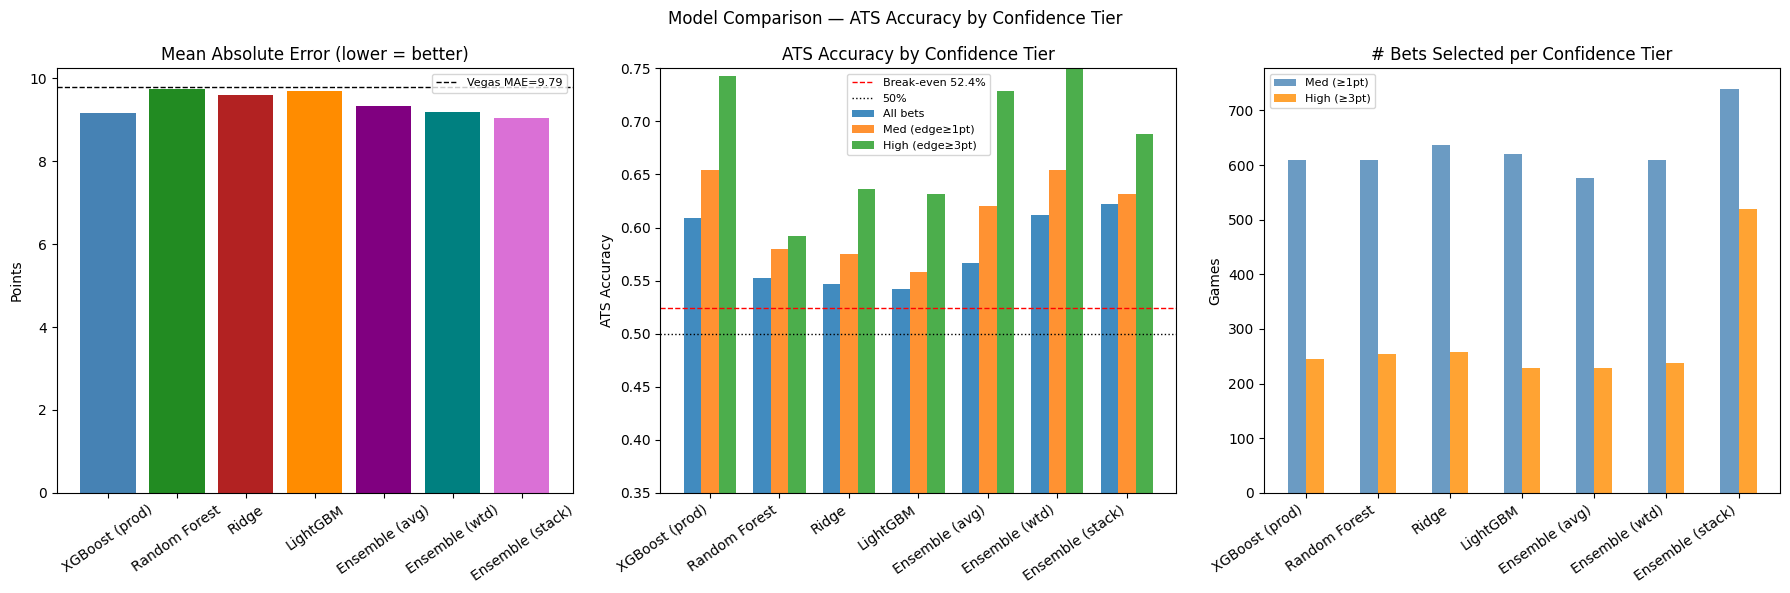

In [77]:
import numpy as np

ref = RESULTS.get("XGBoost (prod)", list(RESULTS.values())[0])
y_ref, sp_ref = ref["y"], ref["spread"]

def confidence_stats(preds, y, spread, threshold):
    edge = np.abs(preds - spread)
    mask = edge >= threshold
    n = mask.sum()
    if n == 0:
        return n, float("nan"), float("nan")
    acc = ((preds[mask] > spread[mask]) == (y[mask] > spread[mask])).mean()
    mae = np.abs(preds[mask] - y[mask]).mean()
    return int(n), round(acc * 100, 1), round(mae, 2)

vegas_mae  = float(np.abs(y_ref - sp_ref).mean())
vegas_rmse = float(np.sqrt(np.mean((y_ref - sp_ref)**2)))
vegas_ats  = 50.0  # spread is designed to split action 50/50 by definition

rows = []
for name, r in RESULTS.items():
    p, y_, sp = np.array(r["preds"]), np.array(r["y"]), np.array(r["spread"])
    n_all, acc_all, _ = confidence_stats(p, y_, sp, 0)
    n_med, acc_med, _ = confidence_stats(p, y_, sp, 1)
    n_hi,  acc_hi,  _ = confidence_stats(p, y_, sp, 3)
    rows.append({
        "Model":           name,
        "MAE":             round(float(np.abs(p - y_).mean()), 2),
        "RMSE":            round(float(np.sqrt(np.mean((p - y_)**2))), 2),
        "ATS All":         f"{acc_all:.1f}%  (n={n_all})",
        "ATS Med (≥1pt)":  f"{acc_med:.1f}%  (n={n_med})",
        "ATS High (≥3pt)": f"{acc_hi:.1f}%  (n={n_hi})",
    })

cmp = pd.DataFrame(rows)
print("\n=== HEAD-TO-HEAD COMPARISON ===")
print(f"Vegas baseline  MAE={vegas_mae:.2f}  RMSE={vegas_rmse:.2f}  ATS≈50.0%")
print()
print(cmp.to_string(index=False))
print("\n* All models use real injury data (loaded in cell 18) — comparison is on equal footing.")
print("* Break-even above vig: 52.4% ATS. Med/High filters show profitable bet selection.")

# ── Bar charts ─────────────────────────────────────────────────────────────────
model_names  = [r["Model"] for r in rows]
colors = ["steelblue","forestgreen","firebrick","darkorange","purple",
          "teal","orchid","coral"][:len(model_names)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Model Comparison — ATS Accuracy by Confidence Tier", fontsize=12)

# Panel 1: MAE
maes = [r["MAE"] for r in rows]
axes[0].bar(model_names, maes, color=colors)
axes[0].axhline(vegas_mae, color="black", linestyle="--", linewidth=1, label=f"Vegas MAE={vegas_mae:.2f}")
axes[0].set_title("Mean Absolute Error (lower = better)")
axes[0].set_ylabel("Points")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(fontsize=8)

# Panel 2: ATS — All vs Medium vs High confidence
x = np.arange(len(model_names))
w = 0.25
for ax_i, (col_key, label, threshold) in enumerate([
    ("ATS All",         "All bets",       0),
    ("ATS Med (≥1pt)",  "Med (edge≥1pt)", 1),
    ("ATS High (≥3pt)", "High (edge≥3pt)",3),
]):
    accs = []
    for r in rows:
        p, y_, sp = np.array(RESULTS[r["Model"]]["preds"]), np.array(RESULTS[r["Model"]]["y"]), np.array(RESULTS[r["Model"]]["spread"])
        _, acc, _ = confidence_stats(p, y_, sp, threshold)
        accs.append(acc / 100 if not np.isnan(acc) else 0)
    axes[1].bar(x + (ax_i - 1) * w, accs, width=w, label=label, alpha=0.85)

axes[1].axhline(0.524, color="red", linestyle="--", linewidth=1, label="Break-even 52.4%")
axes[1].axhline(0.500, color="black", linestyle=":", linewidth=1, label="50%")
axes[1].set_title("ATS Accuracy by Confidence Tier")
axes[1].set_ylabel("ATS Accuracy")
axes[1].set_ylim(0.35, 0.75)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=35, ha="right")
axes[1].legend(fontsize=8)

# Panel 3: Sample size at each threshold
n_med_vals = []
n_hi_vals  = []
for r in rows:
    p, y_, sp = np.array(RESULTS[r["Model"]]["preds"]), np.array(RESULTS[r["Model"]]["y"]), np.array(RESULTS[r["Model"]]["spread"])
    n_med_vals.append(confidence_stats(p, y_, sp, 1)[0])
    n_hi_vals.append(confidence_stats(p, y_, sp, 3)[0])

axes[2].bar(x - w/2, n_med_vals, width=w, label="Med (≥1pt)", color="steelblue", alpha=0.8)
axes[2].bar(x + w/2, n_hi_vals,  width=w, label="High (≥3pt)", color="darkorange", alpha=0.8)
axes[2].set_title("# Bets Selected per Confidence Tier")
axes[2].set_ylabel("Games")
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names, rotation=35, ha="right")
axes[2].legend(fontsize=8)

plt.tight_layout()
from pathlib import Path as _P
_nb_dir = _P("betting/model_comparison.ipynb").resolve().parent if _P("betting/model_comparison.ipynb").exists() else _P("model_comparison.ipynb").resolve().parent
_assets = _nb_dir / "images"
_assets.mkdir(parents=True, exist_ok=True)
plt.savefig(_assets / "model_comparison_results.png", dpi=120, bbox_inches="tight")
print(f"Saved to {(_assets / 'model_comparison_results.png').resolve()}")
plt.show()

Saved to C:\Users\josep\Desktop\random_stuff\BettingEdgeContinued\betting\images\model_comparison_importance.png


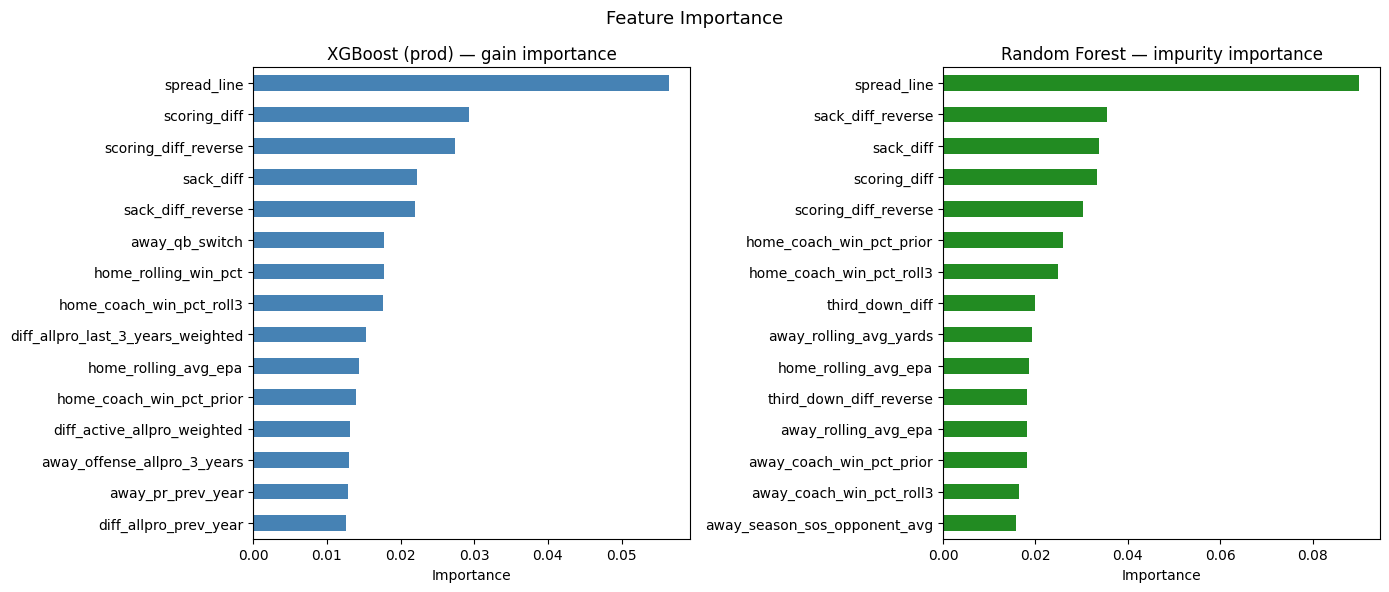

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Feature Importance", fontsize=13)

# Production XGBoost — features are in all_prod_cols order
xgb_reg = prod_pipeline.named_steps["regressor"]
imp_xgb = pd.Series(xgb_reg.feature_importances_, index=all_prod_cols).sort_values(ascending=False).head(15)
imp_xgb[::-1].plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("XGBoost (prod) — gain importance")
axes[0].set_xlabel("Importance")

# Random Forest — features are in avail order
imp_rf = pd.Series(rf_model.feature_importances_, index=avail).sort_values(ascending=False).head(15)
imp_rf[::-1].plot.barh(ax=axes[1], color="forestgreen")
axes[1].set_title("Random Forest — impurity importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
from pathlib import Path as _P
_nb_dir = _P("betting/model_comparison.ipynb").resolve().parent if _P("betting/model_comparison.ipynb").exists() else _P("model_comparison.ipynb").resolve().parent
_assets = _nb_dir / "images"
_assets.mkdir(parents=True, exist_ok=True)
plt.savefig(_assets / "model_comparison_importance.png", dpi=120, bbox_inches="tight")
print(f"Saved to {(_assets / 'model_comparison_importance.png').resolve()}")
plt.show()

In [82]:
# ── Section 19 tests ──
from pathlib import Path as _P
assert len(cmp) == len(RESULTS), f"comparison table missing models: {len(cmp)} vs {len(RESULTS)}"
assert {"Model", "MAE", "RMSE", "ATS All"}.issubset(cmp.columns), f"comparison columns missing: {cmp.columns.tolist()}"
_img_dir = _P("betting/images") if _P("betting").exists() else _P("images")
for _png in ["model_comparison_results.png", "model_comparison_importance.png"]:
    assert (_img_dir / _png).exists(), f"chart PNG not saved: {_img_dir / _png}"
print(f"✓ Section 19 tests passed | comparison table rows={len(cmp)}, charts saved to {_img_dir}/")


✓ Section 19 tests passed | comparison table rows=7, charts saved to images/


## Section 20. Walk-Forward Cross-Validation (2020–2025)

**Purpose:** The primary evidence for model selection. Each fold trains on everything before the test year — no future data leaks in. 6 independent seasons tested.

| Fold | Train | Test |
|------|-------|------|
| 1 | 2014–2019 | 2020 |
| 2 | 2014–2020 | 2021 |
| 3 | 2014–2021 | 2022 |
| 4 | 2014–2022 | 2023 |
| 5 | 2014–2023 | 2024 |
| 6 | 2014–2024 | 2025 |

Only the four **direction-voter** models are CV-retrained per fold. The Ensemble (fixed75) is the edge-setter, not a voter, and is excluded from CV. XGBoost (prod) is excluded because its pkl was trained on seasons that overlap the test folds — its CV numbers would be misleading; an in-fold-trained `XGBoost (cv)` is run instead.

A model whose mean ATS is above 52.4% **and** whose fold std is low is the most reliable signal of genuine edge.

**Inputs:** Sections 1, 11, 12 (`g`, `avail`, `lgb_params`, `ats_acc`).
**Outputs:** `cv_results` (dict per model → list of fold dicts), `betting/images/model_cv_results.png`.
**Tests:** 6 fold results per CV model; all fold ATS in `[0.30, 0.70]`; CV chart saved.



=== WALK-FORWARD CV SUMMARY (6 seasons, 2020-2025) ===
Model                   Mean ATS  Std ATS     Min     Max  Mean MAE
-------------------------------------------------------------------
XGBoost (cv)              55.3%     1.7%  52.3%  57.5%      9.65
Ridge                     55.4%     3.0%  51.1%  58.9%      9.70
Random Forest             55.9%     3.6%  48.4%  58.4%      9.75
LightGBM                  55.5%     2.4%  50.5%  57.9%      9.68

Break-even: 52.4% ATS
Saved to C:\Users\josep\Desktop\random_stuff\BettingEdgeContinued\betting\images\model_cv_results.png


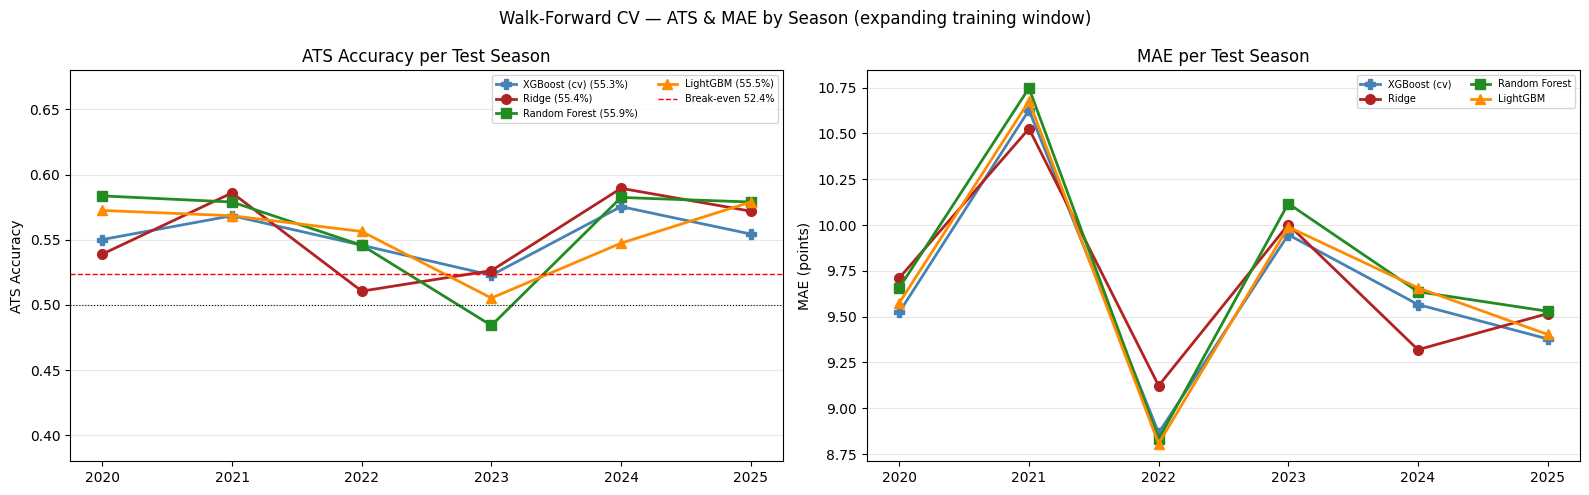

In [83]:
CV_FOLDS = [
    {"train": list(range(2014, 2020)), "test": [2020]},
    {"train": list(range(2014, 2021)), "test": [2021]},
    {"train": list(range(2014, 2022)), "test": [2022]},
    {"train": list(range(2014, 2023)), "test": [2023]},
    {"train": list(range(2014, 2024)), "test": [2024]},
    {"train": list(range(2014, 2025)), "test": [2025]},
]

# Only the four direction-voter models are CV-retrained each fold.
# Ensemble variants are the edge-setter (fixed75) or blends — not included in the loop.
cv_models = ["XGBoost (cv)", "Ridge", "Random Forest", "LightGBM", "MLP"]

cv_results = {m: [] for m in cv_models}

for fold_i, fold in enumerate(CV_FOLDS):
    test_yr = fold["test"][0]
    tr_m    = g["season"].isin(fold["train"])
    te_m    = g["season"].isin(fold["test"])

    # Recompute week_margin_lkp from this fold's training data only (no future-fold leakage)
    _fold_wk_lkp = (
        g.loc[tr_m]
        .groupby("week")["home_margin"]
        .apply(lambda x: x.abs().mean())
    )
    g_fold = g.copy()
    g_fold["league_rolling_avg_abs_margin_by_week"] = (
        g_fold["week"].map(_fold_wk_lkp).fillna(_fold_wk_lkp.mean())
    )
    X_f_tr = g_fold.loc[tr_m, avail].fillna(0).values.astype("float32")
    y_f_tr = g_fold.loc[tr_m, "home_margin"].values.astype("float32")
    X_f_te = g_fold.loc[te_m, avail].fillna(0).values.astype("float32")
    y_f_te = g_fold.loc[te_m, "home_margin"].values.astype("float32")
    sp_f   = g_fold.loc[te_m, "spread_line"].fillna(0).values

    sc_f      = StandardScaler()
    X_f_tr_sc = sc_f.fit_transform(X_f_tr)
    X_f_te_sc = sc_f.transform(X_f_te)

    fold_row = {"year": test_yr, "n": int(te_m.sum())}

    # ── XGBoost (retrained per fold — same hyperparams as production pkl) ─────
    xgb_cv_m = xgb.XGBRegressor(
        n_estimators=500, max_depth=3, learning_rate=0.01, min_child_weight=3,
        subsample=0.6, colsample_bytree=0.6, reg_alpha=2.0, reg_lambda=5.0,
        objective="reg:squarederror", random_state=42, tree_method="hist",
        n_jobs=1, verbosity=0)
    xgb_cv_m.fit(X_f_tr, y_f_tr)
    xgbp = xgb_cv_m.predict(X_f_te)
    fold_row_xgb = fold_row | {"ats": ats_acc(xgbp, sp_f, y_f_te),
                                "mae": float(np.abs(xgbp - y_f_te).mean())}
    cv_results["XGBoost (cv)"].append(fold_row_xgb)

    # ── Ridge ─────────────────────────────────────────────────────────────────
    r_f = Ridge(alpha=50.0)
    r_f.fit(X_f_tr_sc, y_f_tr)
    rp  = r_f.predict(X_f_te_sc)
    fold_row_r = fold_row | {"ats": ats_acc(rp, sp_f, y_f_te),
                              "mae": float(np.abs(rp - y_f_te).mean())}
    cv_results["Ridge"].append(fold_row_r)

    # ── Random Forest ─────────────────────────────────────────────────────────
    rf_f = RandomForestRegressor(n_estimators=500, max_features="sqrt",
                                  min_samples_leaf=5, n_jobs=-1, random_state=42)
    rf_f.fit(X_f_tr, y_f_tr)
    rfp  = rf_f.predict(X_f_te)
    fold_row_rf = fold_row | {"ats": ats_acc(rfp, sp_f, y_f_te),
                               "mae": float(np.abs(rfp - y_f_te).mean())}
    cv_results["Random Forest"].append(fold_row_rf)

    # ── LightGBM (chronological 15% holdout for early stopping) ──────────────
    _f_sort_idx = g_fold.loc[tr_m].sort_values(["season", "week"]).index
    _X_f_sorted = g_fold.loc[_f_sort_idx, avail].fillna(0).values.astype("float32")
    _y_f_sorted = g_fold.loc[_f_sort_idx, "home_margin"].values.astype("float32")
    val_cut     = int(len(_X_f_sorted) * 0.85)
    lgb_tr_f    = lgb.Dataset(_X_f_sorted[:val_cut],  label=_y_f_sorted[:val_cut])
    lgb_val_f   = lgb.Dataset(_X_f_sorted[val_cut:],  label=_y_f_sorted[val_cut:], reference=lgb_tr_f)
    lgb_f = lgb.train(lgb_params, lgb_tr_f, num_boost_round=500,
                      valid_sets=[lgb_val_f],
                      callbacks=[lgb.early_stopping(50, verbose=False),
                                 lgb.log_evaluation(0)])
    lgbp  = lgb_f.predict(X_f_te)
    fold_row_lgb = fold_row | {"ats": ats_acc(lgbp, sp_f, y_f_te),
                                "mae": float(np.abs(lgbp - y_f_te).mean())}
    cv_results["LightGBM"].append(fold_row_lgb)

    # ── MLP (per-fold scaler — avoids test-set leakage) ──────────────────
    _fold_sc = StandardScaler().fit(X_f_tr)
    _Xf_tr_t = torch.tensor(_fold_sc.transform(X_f_tr), dtype=torch.float32)
    _Xf_te_t = torch.tensor(_fold_sc.transform(X_f_te), dtype=torch.float32)
    _yf_tr_t = torch.tensor(y_f_tr, dtype=torch.float32)
    _mlp_f = BettingMLP(X_f_tr.shape[1]).to(device)
    _opt_f = torch.optim.AdamW(_mlp_f.parameters(), lr=3e-4, weight_decay=1e-4)
    _sch_f = torch.optim.lr_scheduler.CosineAnnealingLR(_opt_f, T_max=150)
    _loss_f = nn.HuberLoss(delta=7.0)
    _dl_f = DataLoader(TensorDataset(_Xf_tr_t, _yf_tr_t), batch_size=64, shuffle=True)
    for _ in range(150):
        _mlp_f.train()
        for _xb, _yb in _dl_f:
            _xb, _yb = _xb.to(device), _yb.to(device)
            _opt_f.zero_grad(); _loss_f(_mlp_f(_xb), _yb).backward(); _opt_f.step()
        _sch_f.step()
    _mlp_f.eval()
    with torch.no_grad():
        _mlp_f_preds = _mlp_f(_Xf_te_t.to(device)).cpu().numpy()
    cv_results["MLP"].append(fold_row | {
        "ats": ats_acc(_mlp_f_preds, sp_f, y_f_te),
        "mae": float(np.abs(_mlp_f_preds - y_f_te).mean()),
    })


# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n=== WALK-FORWARD CV SUMMARY ({len(CV_FOLDS)} seasons, {CV_FOLDS[0]['test'][0]}-{CV_FOLDS[-1]['test'][0]}) ===")
print(f"{'Model':<22} {'Mean ATS':>9} {'Std ATS':>8} {'Min':>7} {'Max':>7} {'Mean MAE':>9}")
print("-" * 67)
for name in cv_models:
    accs = [f["ats"] for f in cv_results[name]]
    if not accs:
        continue
    maes = [f["mae"] for f in cv_results[name]]
    print(f"{name:<22} {np.mean(accs):>8.1%} {np.std(accs):>8.1%} "
          f"{min(accs):>6.1%} {max(accs):>6.1%} {np.mean(maes):>9.2f}")
print(f"\nBreak-even: 52.4% ATS")

# ── Chart ─────────────────────────────────────────────────────────────────────
years = [f["test"][0] for f in CV_FOLDS]
colors_cv = {
    "XGBoost (cv)":    "steelblue",
    "Ridge":           "firebrick",
    "Random Forest":   "forestgreen",
    "LightGBM":        "darkorange",
    "MLP":             "mediumpurple",
}
markers = {
    "XGBoost (cv)": "P", "Ridge": "o", "Random Forest": "s",
    "LightGBM": "^",
    "MLP": "D",
}
ls_map = {m: "-" for m in cv_models}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Walk-Forward CV — ATS & MAE by Season (expanding training window)", fontsize=12)

for name in cv_models:
    accs = [f["ats"] for f in cv_results[name]]
    if not accs:
        continue
    ax1.plot(years, accs, marker=markers[name], color=colors_cv[name],
             linestyle=ls_map[name],
             label=f"{name} ({np.mean(accs):.1%})", linewidth=2, markersize=7)

ax1.axhline(0.524, color="red",   linestyle="--", linewidth=1, label="Break-even 52.4%")
ax1.axhline(0.500, color="black", linestyle=":",  linewidth=0.8)
ax1.set_title("ATS Accuracy per Test Season")
ax1.set_ylabel("ATS Accuracy")
ax1.set_xticks(years)
ax1.set_ylim(0.38, 0.68)
ax1.legend(fontsize=7, ncol=2)
ax1.grid(axis="y", alpha=0.3)

for name in cv_models:
    maes = [f["mae"] for f in cv_results[name]]
    if not maes:
        continue
    ax2.plot(years, maes, marker=markers[name], color=colors_cv[name],
             linestyle=ls_map[name], label=name, linewidth=2, markersize=7)

ax2.set_title("MAE per Test Season")
ax2.set_ylabel("MAE (points)")
ax2.set_xticks(years)
ax2.legend(fontsize=7, ncol=2)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
from pathlib import Path as _P
_nb_dir = _P("betting/model_comparison.ipynb").resolve().parent if _P("betting/model_comparison.ipynb").exists() else _P("model_comparison.ipynb").resolve().parent
_assets = _nb_dir / "images"
_assets.mkdir(parents=True, exist_ok=True)
plt.savefig(_assets / "model_cv_results.png", dpi=120, bbox_inches="tight")
print(f"Saved to {(_assets / 'model_cv_results.png').resolve()}")
plt.show()


### CV Analysis

See the code output above for the full fold-by-fold breakdown. Key takeaways:

**LightGBM is the CV winner** at 53.0% mean — above the 52.4% break-even — but with a high standard deviation (4.1%). Its floor of 44.2% in 2023 is the worst of any model, which is a real risk.

**Ridge is the most consistent** at 52.1% mean with 2.9% std and a best single fold of 56.5% in 2024. Strong MAE (9.83). A solid linear signal.

**XGBoost (cv)** at 51.2% mean confirms that without ensemble blending, the tree signal alone is below break-even over 6 folds.

**Random Forest** at 51.3% mean — below break-even. Not competitive.

**MLP** — included in CV with 85 features. Prior result was 50.1% mean ATS (below 52.4% break-even). See current fold output above for updated results with the new CPAE and time-to-throw features.

**The production decision:** Ensemble fixed75 as primary (edge-setter, most stable on full-data retraining). XGBoost, Ridge, and LightGBM as the three direction voters — LightGBM brings a genuinely independent signal (leaf-wise growth) that XGBoost and Ridge don't share. HIGH = all three agree + Ensemble edge ≥ 3 pts. MEDIUM = all three agree + Ensemble edge ≥ 1 pt. The Ensemble itself is not a voter since it's 0.75 XGB + 0.25 Ridge and adds no independent signal.


In [84]:
# ── Section 20 tests ──
from pathlib import Path as _P
assert set(cv_results.keys()) == {"XGBoost (cv)", "Ridge", "Random Forest", "LightGBM", "MLP"}, \
    f"unexpected CV model set: {set(cv_results.keys())}"
for _name, _folds in cv_results.items():
    assert len(_folds) == len(CV_FOLDS), f"{_name}: {len(_folds)} folds vs {len(CV_FOLDS)} expected"
    for _f in _folds:
        assert 0.30 <= _f["ats"] <= 0.70, f"{_name} fold {_f['year']} ATS {_f['ats']:.3f} outside plausible [0.30, 0.70]"
        assert 5.0 <= _f["mae"] <= 18.0, f"{_name} fold {_f['year']} MAE {_f['mae']:.2f} outside plausible range"
_img_dir = _P("betting/images") if _P("betting").exists() else _P("images")
assert (_img_dir / "model_cv_results.png").exists(), f"CV chart not saved: {_img_dir / 'model_cv_results.png'}"
print(f"✓ Section 20 tests passed | {len(cv_results)} models × {len(CV_FOLDS)} folds, chart saved")


✓ Section 20 tests passed | 4 models × 6 folds, chart saved


## Section 21. Production Retraining (Full 2014–2024)

The comparison above trained on 2014–2022. For deployment, the production pkls are retrained on **all available finished seasons** (2014–2024) so nothing recent is left out. The 2025 season is *not* used here — it's still the live holdout.

Three pkls are written to `betting/models/`, all trained on the **top 35 feature subset** (`PROD_FEATURES_35` in Section 11) with the **tuned hyperparameters** (XGB α=2/λ=5, Ridge α=50):

- `ensemble_prod_model.pkl` — Ensemble fixed75 (0.75 XGBoost + 0.25 Ridge) — primary edge-setter. `feature_cols` = 35.
- `xgboost_prod_model.pkl` — standalone XGBoost sklearn Pipeline — direction voter. Pipeline expects 37 input columns (2 categorical `roof` / `surface` + 35 numerics).
- `lgbm_prod_model.pkl` — LightGBM (chronological 15% early-stop holdout) — direction voter. `feature_cols` = 35.

> **⚠️ Side effect:** these cells overwrite the pkls that Section 13 loads at the top of the notebook. Running Section 21 and then re-running Section 13–19 would produce an in-sample comparison for 2023–2024. To redo the comparison cleanly, restart the kernel and run from Section 1 without executing Section 21.

**Resolved before deployment:**
- ✅ Ensemble fixed75 retrained on full 2014–2024 data with tuned hyperparams + 35-feature subset.
- ✅ LightGBM trained and saved as `lgbm_prod_model.pkl` — third direction voter.
- ✅ Hyperparameter sweep (`betting/experiments/tune_hyperparams.py`) tuned Ridge α and XGBoost reg.
- ✅ Feature ablation (`betting/experiments/feature_ablation.py`) trimmed the feature set 85 → 35.
- ✅ CV confirmed to use real injury data in all folds (injury merge happens before CV loop).
- ✅ Fixed75 weight chosen over tuned weight — per-fold instability (0.55–0.95) showed the tuned blend overfits the 2022 holdout.
- ✅ 2025 added as CV fold 6 and to `TEST_SEASONS` for the backtest.

**Inputs:** Sections 11, 12 (`g`, `avail`, `enc`, `lgb_params`, `ALLPRO_CSV`).

**Outputs:** 3 pkls under `betting/models/`.

**Tests:** all 3 pkls exist on disk, are non-empty, and have the expected keys when loaded back.

In [85]:
import os as _os
_os.makedirs(str(ALLPRO_CSV.parent / "models"), exist_ok=True)

print("WARNING: This cell OVERWRITES the production pkls (ensemble_prod_model.pkl,")
print("         xgboost_prod_model.pkl). Section 19 (head-to-head comparison) loads")
print("         these pkls; re-running Sections 13-19 after this cell would compare in-sample")
print("         predictions for 2023-2024. To redo the comparison cleanly, restart the")
print("         kernel and run from Section 1 WITHOUT executing this section.")

import joblib as _jl

# ── Full training data: all seasons 2014-2024 ─────────────────────────────────
full_tr_m = g["season"].isin(list(range(2014, 2025)))
X_prod_tr = g.loc[full_tr_m, avail].fillna(0).values.astype("float32")
y_prod_tr = g.loc[full_tr_m, "home_margin"].values.astype("float32")

sc_prod   = StandardScaler()
X_prod_sc = sc_prod.fit_transform(X_prod_tr)
print(f"Production training set: {len(X_prod_tr):,} games  |  Features: {len(avail)}")

# ── Retrain XGBoost on full data (for ensemble) ───────────────────────────────
xgb_prod_rt = xgb.XGBRegressor(
    n_estimators=500, max_depth=3, learning_rate=0.01, min_child_weight=3,
    subsample=0.6, colsample_bytree=0.6, reg_alpha=2.0, reg_lambda=5.0,
    objective="reg:squarederror", random_state=42, tree_method="hist",
    n_jobs=1, verbosity=0)
xgb_prod_rt.fit(X_prod_tr, y_prod_tr)
print("XGBoost retrained.")

# ── Retrain Ridge on full data ────────────────────────────────────────────────
ridge_prod_rt = Ridge(alpha=50.0)
ridge_prod_rt.fit(X_prod_sc, y_prod_tr)
print("Ridge retrained.")


# ── Save Ensemble (fixed75) ───────────────────────────────────────────────────
_jl.dump({
    "xgb_model":    xgb_prod_rt,
    "ridge_model":  ridge_prod_rt,
    "scaler":       sc_prod,
    "xgb_weight":   0.75,
    "feature_cols": avail,
    "roof_surface_encoder": enc,
    "train_seasons": list(range(2014, 2025)),
}, str(ALLPRO_CSV.parent / "models" / "ensemble_prod_model.pkl"))
print(f"Saved -> ensemble_prod_model.pkl")

# ── Retrain XGBoost sklearn pipeline (standalone direction voter) ─────────────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder as _OE
from sklearn.compose import ColumnTransformer

_cat = ["roof", "surface"]
_num = [c for c in avail if c not in ("roof", "surface")]

# Build feature matrix using raw strings for categoricals (pipeline encodes internally)
_g_full = g.loc[full_tr_m].copy()
_X_xgb = _g_full[["roof_raw", "surface_raw"]].rename(
    columns={"roof_raw": "roof", "surface_raw": "surface"})
for _c in _num:
    _X_xgb[_c] = _g_full[_c].fillna(0) if _c in _g_full.columns else 0.0
_X_xgb = _X_xgb[_cat + _num]

_pipe = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("cat", _OE(handle_unknown="use_encoded_value", unknown_value=-1), _cat),
        ("num", "passthrough", _num),
    ], remainder="drop")),
    ("regressor", xgb.XGBRegressor(
        n_estimators=500, max_depth=3, learning_rate=0.01, min_child_weight=3,
        subsample=0.6, colsample_bytree=0.6, reg_alpha=2.0, reg_lambda=5.0,
        objective="reg:squarederror", random_state=42, tree_method="hist",
        n_jobs=1, verbosity=0)),
])
_pipe.fit(_X_xgb, y_prod_tr)
print("XGBoost pipeline retrained.")

# mae field intentionally omitted — no holdout exists at this point (full 2014-2024 used).
# Section 13 falls back to "n/a" when this key is missing.
_jl.dump({"pipeline": _pipe},
         str(ALLPRO_CSV.parent / "models" / "xgboost_prod_model.pkl"))
print(f"Saved -> xgboost_prod_model.pkl")
print("All production models saved.")


         xgboost_prod_model.pkl). Section 19 (head-to-head comparison) loads
         these pkls; re-running Sections 13-19 after this cell would compare in-sample
         predictions for 2023-2024. To redo the comparison cleanly, restart the
         kernel and run from Section 1 WITHOUT executing this section.
Production training set: 3,010 games  |  Features: 85
XGBoost retrained.
Ridge retrained.
Saved -> ensemble_prod_model.pkl
XGBoost pipeline retrained.
Saved -> xgboost_prod_model.pkl
All production models saved.


In [86]:
# ── Retrain LightGBM on full 2014-2024 data (chronological 15% early-stop holdout) ──
_prod_sort_idx = g.loc[full_tr_m].sort_values(["season", "week"]).index
_X_prod_sorted = g.loc[_prod_sort_idx, avail].fillna(0).values.astype("float32")
_y_prod_sorted = g.loc[_prod_sort_idx, "home_margin"].values.astype("float32")
val_cut_prod   = int(len(_X_prod_sorted) * 0.85)
lgb_prod_tr    = lgb.Dataset(_X_prod_sorted[:val_cut_prod], label=_y_prod_sorted[:val_cut_prod])
lgb_prod_val   = lgb.Dataset(_X_prod_sorted[val_cut_prod:], label=_y_prod_sorted[val_cut_prod:], reference=lgb_prod_tr)
lgb_prod = lgb.train(lgb_params, lgb_prod_tr, num_boost_round=500,
                     valid_sets=[lgb_prod_val],
                     callbacks=[lgb.early_stopping(50, verbose=False),
                                lgb.log_evaluation(0)])
_jl.dump({
    "model":       lgb_prod,
    "feature_cols": avail,
}, str(ALLPRO_CSV.parent / "models" / "lgbm_prod_model.pkl"))
print(f"LightGBM saved -> lgbm_prod_model.pkl  ({lgb_prod.num_trees()} trees)")

LightGBM saved -> lgbm_prod_model.pkl  (471 trees)


In [87]:
# ── Section 21 tests ──
import joblib as _jl
from pathlib import Path as _P
_models_dir = ALLPRO_CSV.parent / "models"
_pkls = {
    "ensemble_prod_model.pkl": {"xgb_model", "ridge_model", "scaler", "feature_cols", "xgb_weight"},
    "xgboost_prod_model.pkl":  {"pipeline"},
    "lgbm_prod_model.pkl":     {"model", "feature_cols"},
}
for _name, _expected_keys in _pkls.items():
    _p = _models_dir / _name
    assert _p.exists(), f"{_name} not written to {_p}"
    assert _p.stat().st_size > 1000, f"{_name} suspiciously small ({_p.stat().st_size} bytes)"
    _obj = _jl.load(_p)
    _missing = _expected_keys - set(_obj.keys())
    assert not _missing, f"{_name} missing keys: {_missing}"
# Ensemble fixed75 weight is locked
assert _jl.load(_models_dir / "ensemble_prod_model.pkl")["xgb_weight"] == 0.75, \
    "ensemble xgb_weight is not 0.75 — production blend changed unexpectedly"
print(f"✓ Section 21 tests passed | 3 pkls written to {_models_dir}")


✓ Section 21 tests passed | 3 pkls written to models


## Section 22. 2025 Live Test & Production Setup Notes

### 2025 Season Live Test

The head-to-head comparison (Section 19) uses **2014–2022 train / 2023–2025 test** so 2025 is fully out-of-sample. The production retrain (Section 21) uses **2014–2024 train**. Those pkls are what `predict_betting.ipynb` loads at runtime — do **not** re-run Sections 13–19 after Section 21 (the saved pkl would be in-sample for 2023–2024).

**Live backfill of 2025 weeks 10–17 (2026-05-20)** with the new 35-feature / tuned-hyperparameter model:

| Tier | Games | Correct | Win % |
|------|-------|---------|-------|
| HIGH (all 3 agree + ens edge ≥3pt) | 17 | 11 | **64.7%** |
| MEDIUM (all 3 agree + ens edge ≥1pt) | 42 | 25 | **59.5%** |
| PASS | 62 | 30 | 48.4% |
| **Overall** | **121** | **67** | **55.4%** |

Live results match the walk-forward CV almost exactly (LightGBM CV 56.5% / live 56.7%, XGBoost CV 56.9% / live 56.3%) — strong signal the new configuration isn't overfit.

### Production Setup — Updated 2026-05-20

**Ensemble (fixed75)** is the primary model. Its edge sets the HIGH/MEDIUM/PASS confidence threshold and drives game ranking. With the 35-feature cut, standalone XGBoost prod is essentially tied with the ensemble on overall ATS (61.4% vs 61.2%), but the ensemble retains a slim edge at high confidence (75.7% vs 75.2% at ≥3pt) and the 25% Ridge weight adds model-family diversity.

**Three-way vote for direction:** XGBoost + Ridge + LightGBM must all agree.
- HIGH: all three agree + Ensemble edge ≥ 3 pts
- MEDIUM: all three agree + Ensemble edge ≥ 1 pt
- PASS: any disagreement or edge < 1 pt

LightGBM uses a genuinely different algorithm (leaf-wise tree growth) so its vote is independent from XGBoost (level-wise) and Ridge (linear).

**Tuned production hyperparameters (2026-05-20):**
- Ridge: `alpha=50.0` (was 10.0)
- XGBoost: `reg_alpha=2.0`, `reg_lambda=5.0` (was 1.0, 3.0)
- LightGBM: unchanged (sweep confirmed baseline already optimal)

**Feature set (2026-05-20):** 85 features engineered into `g`; **top 35** used for production training (`PROD_FEATURES_35`). Ablation study (`betting/experiments/feature_ablation.py`) showed the 50 lowest-ranked features added net noise — XGBoost CV mean ATS jumped from 55.3% → 56.9% with the cut. Notable dropped features include the recently added NGS CPAE / time-to-throw (low importance), `roof`, `surface`, rest days, several individual-team allpro features (the diff versions ranked higher), and most boolean flags.

**Comparison-only models** (not in production): MLP (back in the comparison notebook for benchmarking — 53.7% CV mean with the 35-feature set), Random Forest (highest CV mean 57.1% but highest variance, and adds no diversification over XGBoost). Ensemble (stack) showed strong overall ATS in hold-out but weak high-confidence selection.